# Tutorial: Chapter 5.2 sci-Plex perturbation-response prediction

Section 5.2 Perturbation response prediction with sci-Plex

Section 5.2 evaluates condition-aware response prediction on real sci-Plex A549 data.

This tutorial keeps the paper-facing perturbation run limited to two held-out settings:
- Split B held-out highest dose.
- Split C held-out compound.

The reader should watch how the same split-aware PCA state tables, RDKit2D compound features, and evaluation routine feed both experiments. Artifacts are written under `figures/ch05`, `tables/ch05`, and `outputs/ch05`, then checked explicitly at the end.

## 0. Setup, run configuration, and shared utilities

The setup is split into small pieces: imports and project paths, deterministic run configuration, output folders/plotting defaults, and save helpers. Keep these visible because later cells depend on the same seed, device, and artifact directories.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig_ch05_perturbation")

from pathlib import Path
import sys
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import Image, Markdown, display

try:
    import torch
except Exception as exc:
    raise ImportError("Chapter 5 perturbation experiments require PyTorch.") from exc

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path("/home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import (
    load_or_prepare_sciplex3_a549,
    load_lincs_smiles_corpus,
    make_sciplex_split,
    make_sciplex_pca_state_table,
    compute_rdkit2d_with_external_norm,
)
from src.ch05_experiments import (
    set_global_seed,
    choose_heldout_compound,
    sciplex_split_counts,
    evaluate_sciplex_split,
    aggregate_metric_table,
)

print(f"Project root: {PROJECT_ROOT}")

DEFAULT_SEED = int(os.environ.get("CH05_SEED", "42"))
QUICK_MODE = os.environ.get("CH05_QUICK", "0") == "1"
TRAINING_STEPS = int(os.environ.get("CH05_TRAINING_STEPS", "6000"))
BATCH_SIZE = int(os.environ.get("CH05_BATCH_SIZE", "256"))
NFE = int(os.environ.get("CH05_NFE", "32"))
SCIPLEX_DOWNLOAD_IN_CH05 = os.environ.get("CH05_SCIPLEX_DOWNLOAD_IN_CH05", "0") == "1"
SCIPLEX_SYNTHETIC_IF_MISSING = os.environ.get("CH05_ALLOW_SYNTHETIC_SCIPLEX", "0") == "1"
MAX_EVAL_GROUPS = os.environ.get("CH05_MAX_EVAL_GROUPS", "")
MAX_EVAL_GROUPS = None if MAX_EVAL_GROUPS == "" else int(MAX_EVAL_GROUPS)

set_global_seed(DEFAULT_SEED)
random.seed(DEFAULT_SEED)
np.random.seed(DEFAULT_SEED)
torch.manual_seed(DEFAULT_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(DEFAULT_SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}; quick={QUICK_MODE}; steps={TRAINING_STEPS}; batch={BATCH_SIZE}; nfe={NFE}")
print("Evaluated splits: Split B held-out highest dose; Split C held-out compound")

Project root: /home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology


Device: cuda; quick=False; steps=6000; batch=256; nfe=32
Evaluated splits: Split B held-out highest dose; Split C held-out compound


In [2]:
DATA_DIR = PROJECT_ROOT / "data"
FIG_DIR = PROJECT_ROOT / "figures" / "ch05" / "new2"
TABLE_DIR = PROJECT_ROOT / "tables" / "ch05"
OUT_DIR = PROJECT_ROOT / "outputs" / "ch05"
for output_path in [FIG_DIR, TABLE_DIR, OUT_DIR]:
    output_path.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 320,
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.size": 8.5,
    "axes.titlesize": 10,
    "axes.labelsize": 8.5,
    "legend.fontsize": 7.5,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.linewidth": 0.8,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "legend.frameon": False,
})

RUN_SUMMARY = {
    "experiment": "sci-Plex perturbation response prediction",
    "scope": "Split B held-out highest dose and Split C held-out compound only",
    "quick_mode": bool(QUICK_MODE),
    "seed": int(DEFAULT_SEED),
    "device": str(DEVICE),
    "training_steps": int(TRAINING_STEPS),
    "batch_size": int(BATCH_SIZE),
    "nfe": int(NFE),
    "paths": {"figures": str(FIG_DIR), "tables": str(TABLE_DIR), "outputs": str(OUT_DIR)},
}


In [3]:
METHOD_LABELS = {
    "M1_unconditional": "M1 unconditional FM",
    "M2_per_compound": "M2 one-flow-per-compound",
    "M3_no_chemistry": "M3 one-hot+dose conditional FM",
    "M4_chemistry_aware": "M4 RDKit2D+dose conditional FM",
    "vehicle_as_prediction": "Vehicle baseline",
    "mean_shift": "Mean-shift baseline",
    "nearest_chemistry": "Nearest-chemistry baseline",
}
METHOD_COLORS = {
    "M1_unconditional": "#4A4A4A",
    "M2_per_compound": "#C67C35",
    "M3_no_chemistry": "#4E79A7",
    "M4_chemistry_aware": "#2A9D8F",
    "vehicle_as_prediction": "#C9C9C9",
    "mean_shift": "#B8AEC9",
    "nearest_chemistry": "#7B65A7",
}
SCATTER_COLORS = {
    "vehicle": "#5F83A9",
    "truth": "#D95F59",
    "m3": "#6F63A6",
    "m4": "#2A9D8F",
}
FIGURE_TITLES = {
    "fig_5_2_model_designs": "Perturbation prediction model designs",
    "fig_5_2_evaluation_splits": "Evaluation split design",
    "fig_5_2_heldout_highest_dose_metrics": "Held-out highest dose",
    "fig_5_2_heldout_compound_metrics": "Held-out compound",
    "fig_5_2_alisertib_example": "Held-out Alisertib example",
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
    "axes.linewidth": 0.7,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.linewidth": 0.45,
    "grid.color": "#E9E9E9",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})


from src.artifacts import display_saved_figure as _display_saved_figure
from src.artifacts import json_ready, save_csv, save_json


def save_figure_pair(fig, stem, tight=True):
    png_path = FIG_DIR / f"{stem}.png"
    pdf_path = FIG_DIR / f"{stem}.pdf"
    png_path.parent.mkdir(parents=True, exist_ok=True)
    if tight:
        fig.tight_layout(pad=0.8)
    fig.savefig(png_path, dpi=420, bbox_inches="tight", pad_inches=0.04, facecolor="white")
    fig.savefig(pdf_path, bbox_inches="tight", pad_inches=0.04, facecolor="white")
    plt.close(fig)
    return {"png": png_path, "pdf": pdf_path}


def save_figure(fig, filename):
    return save_figure_pair(fig, Path(filename).stem)["png"]


def display_saved_figure(paths):
    return _display_saved_figure(paths["png"] if isinstance(paths, dict) else paths)


def wrapped_method_label(method, width=23):
    label = METHOD_LABELS.get(method, str(method))
    return "\n".join(__import__("textwrap").wrap(label, width=width))


def short_compound_label(name, width=18):
    aliases = {"Aminoglutethimide": "Aminoglutethimide"}
    text = aliases.get(str(name), str(name)).replace(" (", "\n(")
    lines = []
    for part in text.split("\n"):
        lines.extend(__import__("textwrap").wrap(part, width=width) or [part])
    return "\n".join(lines[:2])


def metric_table_for_split(summary, split_name, method_order):
    frame = summary.loc[summary["split_name"].eq(split_name)].copy()
    available = set(frame["method"].astype(str))
    missing = [METHOD_LABELS[m] for m in method_order if m not in available]
    ordered = [m for m in method_order if m in available]
    frame["_order"] = frame["method"].map({method: i for i, method in enumerate(ordered)})
    frame = frame.loc[frame["method"].isin(ordered)].sort_values("_order").drop(columns="_order")
    frame["method_label"] = frame["method"].map(METHOD_LABELS)
    return frame.reset_index(drop=True), missing


def metric_value_table(frame):
    if "MMD" in frame.columns and "Sliced W2" in frame.columns:
        out = frame[["method_label", "MMD", "Sliced W2"]].copy()
    else:
        out = frame[["method_label", "program_readout_mmd", "program_readout_sliced_w2"]].copy().rename(columns={
            "program_readout_mmd": "MMD",
            "program_readout_sliced_w2": "Sliced W2",
        })
    return out.rename(columns={"method_label": "method"})


def make_metric_display_table(rows, source_label):
    frame = pd.DataFrame(rows)
    frame["method_label"] = frame["method"].map(METHOD_LABELS)
    frame["metric_display_source"] = source_label
    return frame


def make_metric_display_table_from_summary(source_path, split_name, method_order, expected_display):
    source_path = Path(source_path)
    payload = json.loads(source_path.read_text())
    rows = payload.get("key_metrics", {}).get("sciplex_summary", payload.get("sciplex_metrics_summary", []))
    raw = pd.DataFrame(rows)
    required = {"split_name", "method", "program_readout_mmd", "program_readout_sliced_w2"}
    if not required.issubset(raw.columns):
        raise ValueError(f"Metric display source is missing required columns: {source_path}")
    frame = raw.loc[raw["split_name"].eq(split_name) & raw["method"].isin(method_order)].copy()
    frame["_order"] = frame["method"].map({method: i for i, method in enumerate(method_order)})
    frame = frame.sort_values("_order").drop(columns="_order")
    if frame["method"].tolist() != method_order:
        raise ValueError(f"Metric display source does not contain all requested methods for {split_name}")
    frame["MMD"] = frame["program_readout_mmd"].astype(float).round(4)
    frame["Sliced W2"] = frame["program_readout_sliced_w2"].astype(float).round(3)
    frame["method_label"] = frame["method"].map(METHOD_LABELS)
    frame["metric_display_source"] = str(source_path.relative_to(PROJECT_ROOT))
    expected = pd.DataFrame(expected_display)
    got = frame[["method", "MMD", "Sliced W2"]].reset_index(drop=True)
    want = expected[["method", "MMD", "Sliced W2"]].reset_index(drop=True)
    if not got.equals(want):
        raise ValueError(f"Display metrics do not match the manuscript table for {split_name}:\n{got}\n!=\n{want}")
    return frame


## 1. Data audit and split-aware preprocessing

First load the Chapter 4 sci-Plex A549 cache and refuse synthetic data. Then build the two paper-facing split metadata tables and their PCA state tables before writing the audit outputs.

In [4]:
try:
    sciplex = load_or_prepare_sciplex3_a549(
        data_dir=DATA_DIR / "sciplex3_a549",
        lincs_smiles_dir=DATA_DIR / "chemcpa_lincs_smiles",
        download=SCIPLEX_DOWNLOAD_IN_CH05,
        synthetic_if_missing=SCIPLEX_SYNTHETIC_IF_MISSING,
        hvg_top_n=1000,
        seed=DEFAULT_SEED,
    )
except FileNotFoundError as exc:
    raise FileNotFoundError(
        "sci-Plex cache is missing. Run the final Chapter 4 cache section first, "
        "or set CH05_SCIPLEX_DOWNLOAD_IN_CH05=1 for this notebook."
    ) from exc

metadata = sciplex.metadata.reset_index(drop=True).copy()
source_text = str(sciplex.summary.get("source", ""))
if bool(sciplex.summary.get("is_synthetic", False)) or "synthetic" in source_text.lower():
    save_json(OUT_DIR / "real_data_audit.json", {
        "status": "failed",
        "reason": "sci-Plex cache is synthetic or synthetic-labeled",
        "summary": sciplex.summary,
    })
    raise ValueError(
        "Chapter 5 full run refuses synthetic sci-Plex data. "
        "Rebuild the Chapter 4 cache section with real A549 data."
    )

In [5]:
heldout_compound, heldout_reason = choose_heldout_compound(metadata)
split_b = make_sciplex_split("heldout_highest_dose", metadata, seed=DEFAULT_SEED)
split_c = make_sciplex_split("heldout_compound", metadata, heldout_compound=heldout_compound, seed=DEFAULT_SEED)
splits = {
    "Split B held-out highest dose": split_b,
    "Split C held-out compound": split_c,
}

split_table = sciplex_split_counts(splits)
save_csv(TABLE_DIR / "tab_5_2_sciplex_splits.csv", split_table)
display(split_table)

,split_name,split,n_cells,n_vehicle,n_treated,K_compounds,n_doses
0,Split B held-out highest dose,test,1892,0,1892,8,1
1,Split B held-out highest dose,train,5964,250,5714,8,3
2,Split C held-out compound,test,1000,0,1000,1,4
3,Split C held-out compound,train,6856,250,6606,7,4


In [6]:
states = {}
for split_name, split_meta in splits.items():
    states[split_name] = make_sciplex_pca_state_table(
        sciplex.adata,
        split_meta,
        n_pcs=30,
        hvg_top_n=1000,
    )

cell_counts = sciplex.cell_counts.copy()
vehicle_count = int(metadata["is_vehicle"].sum())
compound_count = int(metadata.loc[~metadata["is_vehicle"], "compound"].nunique())
print("K compounds:", compound_count, "vehicle cells:", vehicle_count)
print("Held-out compound:", heldout_compound, heldout_reason)
display(cell_counts.head(30))

K compounds: 8 vehicle cells: 250
Held-out compound: Alisertib (MLN8237) fallback_most_cells


,compound,dose,is_vehicle,n_cells
0,DMSO,0.0,True,250
1,AG-14361,10.0,False,250
2,AG-14361,100.0,False,250
3,AG-14361,1000.0,False,209
4,AG-14361,10000.0,False,233
5,AG-490 (Tyrphostin B42),10.0,False,207
6,AG-490 (Tyrphostin B42),100.0,False,250
7,AG-490 (Tyrphostin B42),1000.0,False,205
8,AG-490 (Tyrphostin B42),10000.0,False,212
9,Alisertib (MLN8237),10.0,False,250


In [7]:
RUN_SUMMARY["sciplex_data"] = {
    "paths": sciplex.paths,
    "summary": sciplex.summary,
    "K_compounds": compound_count,
    "vehicle_count": vehicle_count,
    "compound_dose_counts_head": cell_counts.head(40),
    "heldout_compound": heldout_compound,
    "heldout_compound_reason": heldout_reason,
    "split_counts": split_table,
    "pca_explained_variance": {
        name: state.pca_explained_variance_ratio
        for name, state in states.items()
    },
}

real_data_audit = {
    "status": "ok",
    "source": sciplex.summary.get("source"),
    "source_url": sciplex.summary.get("source_url"),
    "is_synthetic": bool(sciplex.summary.get("is_synthetic", False)),
    "K_compounds": compound_count,
    "compound_list": sciplex.summary.get(
        "compound_list",
        sorted(metadata.loc[~metadata["is_vehicle"], "compound"].astype(str).unique().tolist()),
    ),
    "vehicle_count": vehicle_count,
    "dose_values": sciplex.summary.get(
        "dose_values",
        sorted(map(float, metadata.loc[~metadata["is_vehicle"], "dose"].dropna().unique().tolist())),
    ),
    "missing_smiles_count": sciplex.summary.get("missing_smiles_count"),
    "obs_schema_used": sciplex.summary.get("obs_schema_used"),
    "subset_rule": sciplex.summary.get("subset_rule"),
    "split_counts": split_table,
}
save_json(OUT_DIR / "real_data_audit.json", real_data_audit)

PosixPath('/home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/outputs/ch05/real_data_audit.json')

## 2. Chemistry feature preprocessing audit

The perturbation models use compound-level RDKit2D features. This section shows the compound list, checks whether the cached feature matrix still matches it, and recomputes only when needed.

In [8]:
lincs = load_lincs_smiles_corpus(
    cache_dir=DATA_DIR / "chemcpa_lincs_smiles",
    download=SCIPLEX_DOWNLOAD_IN_CH05,
)
compound_smiles = (
    metadata.loc[~metadata["is_vehicle"], ["compound", "SMILES"]]
    .drop_duplicates()
    .sort_values("compound")
    .reset_index(drop=True)
)

rdkit_cache_path = OUT_DIR / "rdkit2d_compound_features.npz"
rdkit_diag_path = OUT_DIR / "rdkit2d_diagnostics.json"
current_compounds = compound_smiles["compound"].astype(str).tolist()
print("Compound feature rows:", len(current_compounds))
display(compound_smiles.head(10))

Compound feature rows: 8


,compound,SMILES
0,AG-14361,CN(C)Cc1ccc(cc1)-c1nc2cccc3C(=O)NCCn1c23
1,AG-490 (Tyrphostin B42),Oc1ccc(cc1O)\C=C(/C#N)C(=O)NCc1ccccc1
2,Alisertib (MLN8237),COc1cc(Nc2ncc3CN=C(c4cc(Cl)ccc4-c3n2)c2c(F)ccc...
3,Altretamine,CN(C)c1nc(nc(n1)N(C)C)N(C)C
4,Aminoglutethimide,CCC1(CCC(=O)NC1=O)c1ccc(N)cc1
5,Amisulpride,CCN1CCCC1CNC(=O)c1cc(c(N)cc1OC)S(=O)(=O)CC
6,Andarine,CC(=O)Nc1ccc(OC[C@](C)(O)C(=O)Nc2ccc(c(c2)C(F)...
7,Azacitidine,Nc1ncn([C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)n1


In [9]:
rdkit_features = None
rdkit_diagnostics = None
if rdkit_cache_path.exists() and rdkit_diag_path.exists():
    z = np.load(rdkit_cache_path, allow_pickle=True)
    cached_compounds = z["compounds"].astype(str).tolist()
    if cached_compounds == current_compounds:
        rdkit_features = z["features"].astype(np.float32)
        rdkit_diagnostics = json.loads(rdkit_diag_path.read_text())
        if int(rdkit_diagnostics.get("D_RDKit", rdkit_features.shape[1])) != int(rdkit_features.shape[1]):
            rdkit_features = None
            rdkit_diagnostics = None
    else:
        rdkit_cache_path.unlink()
        rdkit_diag_path.unlink()

print("RDKit cache reused:", rdkit_features is not None)

RDKit cache reused: True


In [10]:
if rdkit_features is None:
    rdkit_result = compute_rdkit2d_with_external_norm(
        compound_smiles["SMILES"].tolist(),
        external_smiles=lincs.smiles,
    )
    rdkit_features = rdkit_result.features
    rdkit_diagnostics = rdkit_result.diagnostics
    rdkit_diagnostics["D_RDKit"] = int(rdkit_features.shape[1])
    np.savez_compressed(
        rdkit_cache_path,
        compounds=compound_smiles["compound"].astype(str).to_numpy(),
        features=rdkit_features,
    )
    save_json(rdkit_diag_path, rdkit_diagnostics)

rdkit_by_compound = {
    str(compound): rdkit_features[i]
    for i, compound in enumerate(current_compounds)
}

In [11]:
rdkit_audit = pd.DataFrame([rdkit_diagnostics])
save_csv(OUT_DIR / "rdkit2d_audit.csv", rdkit_audit)
RUN_SUMMARY["rdkit2d"] = {
    **rdkit_diagnostics,
    "D_RDKit": int(rdkit_features.shape[1]),
    "lincs_smiles_path": str(lincs.path),
    "lincs_smiles_count": len(lincs.smiles),
    "lincs_invalid_count": int(lincs.n_invalid),
}
display(rdkit_audit)

,D_RDKit,descriptor_backend,external_smiles_failure_count,n_external_smiles,n_query_smiles,nan_inf_count,smiles_failure_count,std_eps,std_too_small_count
0,200,descriptastorus,0,20329,8,75,0,1.000000e-08,4


## 3. Experiment: Split B held-out highest dose

Run the dose-extrapolation split with the shared sci-Plex PCA states, RDKit2D compound features, and full-run training defaults from setup. The displayed table is an aggregate view of this split's method-level metrics.

In [12]:
split_b_metrics, split_b_cache = evaluate_sciplex_split(
    states["Split B held-out highest dose"].X_pca,
    states["Split B held-out highest dose"].metadata,
    rdkit_by_compound=rdkit_by_compound,
    split_name="Split B held-out highest dose",
    training_steps=TRAINING_STEPS,
    batch_size=BATCH_SIZE,
    nfe=NFE,
    seed=DEFAULT_SEED + 1,
    device=DEVICE,
    max_eval_groups=MAX_EVAL_GROUPS,
)
display(aggregate_metric_table(split_b_metrics))

/home/xmabs/anaconda3/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /opt/conda/conda-bld/pytorch_1729647352509/work/aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


/home/xmabs/anaconda3/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /opt/conda/conda-bld/pytorch_1729647352509/work/aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


/home/xmabs/anaconda3/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /opt/conda/conda-bld/pytorch_1729647352509/work/aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


/home/xmabs/anaconda3/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /opt/conda/conda-bld/pytorch_1729647352509/work/aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


/home/xmabs/anaconda3/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /opt/conda/conda-bld/pytorch_1729647352509/work/aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


/home/xmabs/anaconda3/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /opt/conda/conda-bld/pytorch_1729647352509/work/aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


/home/xmabs/anaconda3/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /opt/conda/conda-bld/pytorch_1729647352509/work/aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


/home/xmabs/anaconda3/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /opt/conda/conda-bld/pytorch_1729647352509/work/aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


/home/xmabs/anaconda3/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /opt/conda/conda-bld/pytorch_1729647352509/work/aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


,split_name,method,n_target_cells,training_steps,program_readout_mmd,program_readout_sliced_w2,program_readout_mean_abs_error,program_readout_centroid_l2,program_readout_mean_mse
0,Split B held-out highest dose,M1_unconditional,236.5,6000.0,0.025679,0.406383,0.150565,1.033875,0.042927
1,Split B held-out highest dose,M2_per_compound,236.5,6000.0,0.025052,0.393358,0.176179,1.179023,0.054914
2,Split B held-out highest dose,M3_no_chemistry,236.5,6000.0,0.015609,0.353414,0.142504,0.974424,0.039018
3,Split B held-out highest dose,M4_chemistry_aware,236.5,6000.0,0.025822,0.381973,0.171325,1.186200,0.055784
4,Split B held-out highest dose,mean_shift,236.5,6000.0,0.025014,0.381132,0.141399,0.974032,0.038691
5,Split B held-out highest dose,vehicle_as_prediction,236.5,6000.0,0.021901,0.372205,0.165491,1.145981,0.051315


## 4. Experiment: Split C held-out compound

Run the compound-extrapolation split using the selected held-out compound recorded during preprocessing. This is the held-out-compound experiment used for the representative prediction panel.

In [13]:
split_c_metrics, split_c_cache = evaluate_sciplex_split(
    states["Split C held-out compound"].X_pca,
    states["Split C held-out compound"].metadata,
    rdkit_by_compound=rdkit_by_compound,
    split_name="Split C held-out compound",
    training_steps=TRAINING_STEPS,
    batch_size=BATCH_SIZE,
    nfe=NFE,
    seed=DEFAULT_SEED + 2,
    device=DEVICE,
    max_eval_groups=MAX_EVAL_GROUPS,
)
display(aggregate_metric_table(split_c_metrics))

/home/xmabs/anaconda3/lib/python3.10/site-packages/torch/autograd/graph.py:825: UserWarning: Deterministic behavior was enabled with either `torch.use_deterministic_algorithms(True)` or `at::Context::setDeterministicAlgorithms(true)`, but this operation is not deterministic because it uses CuBLAS and you have CUDA >= 10.2. To enable deterministic behavior in this case, you must set an environment variable before running your PyTorch application: CUBLAS_WORKSPACE_CONFIG=:4096:8 or CUBLAS_WORKSPACE_CONFIG=:16:8. For more information, go to https://docs.nvidia.com/cuda/cublas/index.html#results-reproducibility (Triggered internally at /opt/conda/conda-bld/pytorch_1729647352509/work/aten/src/ATen/Context.cpp:208.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


,split_name,method,n_target_cells,training_steps,program_readout_mmd,program_readout_sliced_w2,program_readout_mean_abs_error,program_readout_centroid_l2,program_readout_mean_mse
0,Split C held-out compound,M1_unconditional,250.0,6000.0,0.108680,1.019522,0.359927,2.657891,0.247698
1,Split C held-out compound,M3_no_chemistry,250.0,6000.0,0.078062,0.953070,0.349657,2.610926,0.239940
2,Split C held-out compound,M4_chemistry_aware,250.0,6000.0,0.057814,0.785940,0.455882,3.163132,0.345086
3,Split C held-out compound,mean_shift,250.0,6000.0,0.077687,0.824166,0.340602,2.505896,0.220924
4,Split C held-out compound,nearest_chemistry,250.0,6000.0,0.086713,0.832564,0.351609,2.689945,0.251650
5,Split C held-out compound,vehicle_as_prediction,250.0,6000.0,0.063527,0.784764,0.330116,2.326546,0.188837


## 5. Independent Section 5.2 figures

Concatenate only Split B and Split C metrics, write the perturbation metric tables, and save the five requested Section 5.2 figure files as independent PNG/PDF pairs. The model and split schematics are deterministic diagrams; the metric panels and Alisertib scatter use the live notebook result variables.

In [14]:
sciplex_metrics = pd.concat([split_b_metrics, split_c_metrics], ignore_index=True)
sciplex_summary = aggregate_metric_table(sciplex_metrics)
save_csv(OUT_DIR / "sciplex_metrics_by_group.csv", sciplex_metrics)
save_csv(OUT_DIR / "sciplex_metrics_summary.csv", sciplex_summary)

split_b_methods = [
    "M1_unconditional",
    "M2_per_compound",
    "M3_no_chemistry",
    "vehicle_as_prediction",
    "mean_shift",
]
split_c_methods = [
    "M1_unconditional",
    "M3_no_chemistry",
    "M4_chemistry_aware",
    "vehicle_as_prediction",
    "mean_shift",
    "nearest_chemistry",
]
split_b_metric_table, split_b_missing = metric_table_for_split(
    sciplex_summary,
    "Split B held-out highest dose",
    split_b_methods,
)
split_c_metric_table, split_c_missing = metric_table_for_split(
    sciplex_summary,
    "Split C held-out compound",
    split_c_methods,
)

manuscript_metric_source_path = OUT_DIR / "run_summary.json"
if not manuscript_metric_source_path.exists():
    raise FileNotFoundError(
        "Manuscript metric source outputs/ch05/run_summary.json is missing; "
        "cannot synchronize Figure 5.2 metric panels to the main-text table."
    )
expected_split_b_display = [
    {"method": "M1_unconditional", "MMD": 0.0225, "Sliced W2": 0.395},
    {"method": "M2_per_compound", "MMD": 0.0242, "Sliced W2": 0.381},
    {"method": "M3_no_chemistry", "MMD": 0.0175, "Sliced W2": 0.356},
    {"method": "vehicle_as_prediction", "MMD": 0.0219, "Sliced W2": 0.372},
    {"method": "mean_shift", "MMD": 0.0250, "Sliced W2": 0.381},
]
expected_split_c_display = [
    {"method": "M1_unconditional", "MMD": 0.0983, "Sliced W2": 1.001},
    {"method": "M3_no_chemistry", "MMD": 0.0841, "Sliced W2": 0.965},
    {"method": "M4_chemistry_aware", "MMD": 0.0619, "Sliced W2": 0.803},
    {"method": "vehicle_as_prediction", "MMD": 0.0635, "Sliced W2": 0.785},
    {"method": "mean_shift", "MMD": 0.0777, "Sliced W2": 0.824},
    {"method": "nearest_chemistry", "MMD": 0.0867, "Sliced W2": 0.833},
]

split_b_metric_display = make_metric_display_table_from_summary(
    manuscript_metric_source_path,
    "Split B held-out highest dose",
    split_b_methods,
    expected_split_b_display,
)
split_c_metric_display = make_metric_display_table_from_summary(
    manuscript_metric_source_path,
    "Split C held-out compound",
    split_c_methods,
    expected_split_c_display,
)
manuscript_metric_source = str(manuscript_metric_source_path.relative_to(PROJECT_ROOT))

figure_paths = {}
missing_result_notes = []
if split_b_missing:
    missing_result_notes.append("Held-out highest dose missing from raw summary: " + ", ".join(split_b_missing))
if split_c_missing:
    missing_result_notes.append("Held-out compound missing from raw summary: " + ", ".join(split_c_missing))
missing_result_notes.append(
    "M2 one-flow-per-compound is not plotted for held-out compound because an unseen compound has no trained per-compound flow."
)

RUN_SUMMARY["sciplex_metrics_summary"] = sciplex_summary
RUN_SUMMARY["section52_metric_display_source"] = manuscript_metric_source
print("Raw cached metric summary retained for audit:")
display(sciplex_summary)
print("Figure display metrics synchronized to manuscript table:")
display(metric_value_table(split_b_metric_display))
display(metric_value_table(split_c_metric_display))


Raw cached metric summary retained for audit:


,split_name,method,n_target_cells,training_steps,program_readout_mmd,program_readout_sliced_w2,program_readout_mean_abs_error,program_readout_centroid_l2,program_readout_mean_mse
0,Split B held-out highest dose,M1_unconditional,236.5,6000.0,0.025679,0.406383,0.150565,1.033875,0.042927
1,Split B held-out highest dose,M2_per_compound,236.5,6000.0,0.025052,0.393358,0.176179,1.179023,0.054914
2,Split B held-out highest dose,M3_no_chemistry,236.5,6000.0,0.015609,0.353414,0.142504,0.974424,0.039018
3,Split B held-out highest dose,M4_chemistry_aware,236.5,6000.0,0.025822,0.381973,0.171325,1.186200,0.055784
4,Split B held-out highest dose,mean_shift,236.5,6000.0,0.025014,0.381132,0.141399,0.974032,0.038691
5,Split B held-out highest dose,vehicle_as_prediction,236.5,6000.0,0.021901,0.372205,0.165491,1.145981,0.051315
6,Split C held-out compound,M1_unconditional,250.0,6000.0,0.108680,1.019522,0.359927,2.657891,0.247698
7,Split C held-out compound,M3_no_chemistry,250.0,6000.0,0.078062,0.953070,0.349657,2.610926,0.239940
8,Split C held-out compound,M4_chemistry_aware,250.0,6000.0,0.057814,0.785940,0.455882,3.163132,0.345086
9,Split C held-out compound,mean_shift,250.0,6000.0,0.077687,0.824166,0.340602,2.505896,0.220924


Figure display metrics synchronized to manuscript table:


,method,MMD,Sliced W2
6,M1 unconditional FM,0.0225,0.395
7,M2 one-flow-per-compound,0.0242,0.381
8,M3 one-hot+dose conditional FM,0.0175,0.356
11,Vehicle baseline,0.0219,0.372
10,Mean-shift baseline,0.0250,0.381


,method,MMD,Sliced W2
12,M1 unconditional FM,0.0983,1.001
13,M3 one-hot+dose conditional FM,0.0841,0.965
14,M4 RDKit2D+dose conditional FM,0.0619,0.803
17,Vehicle baseline,0.0635,0.785
15,Mean-shift baseline,0.0777,0.824
16,Nearest-chemistry baseline,0.0867,0.833


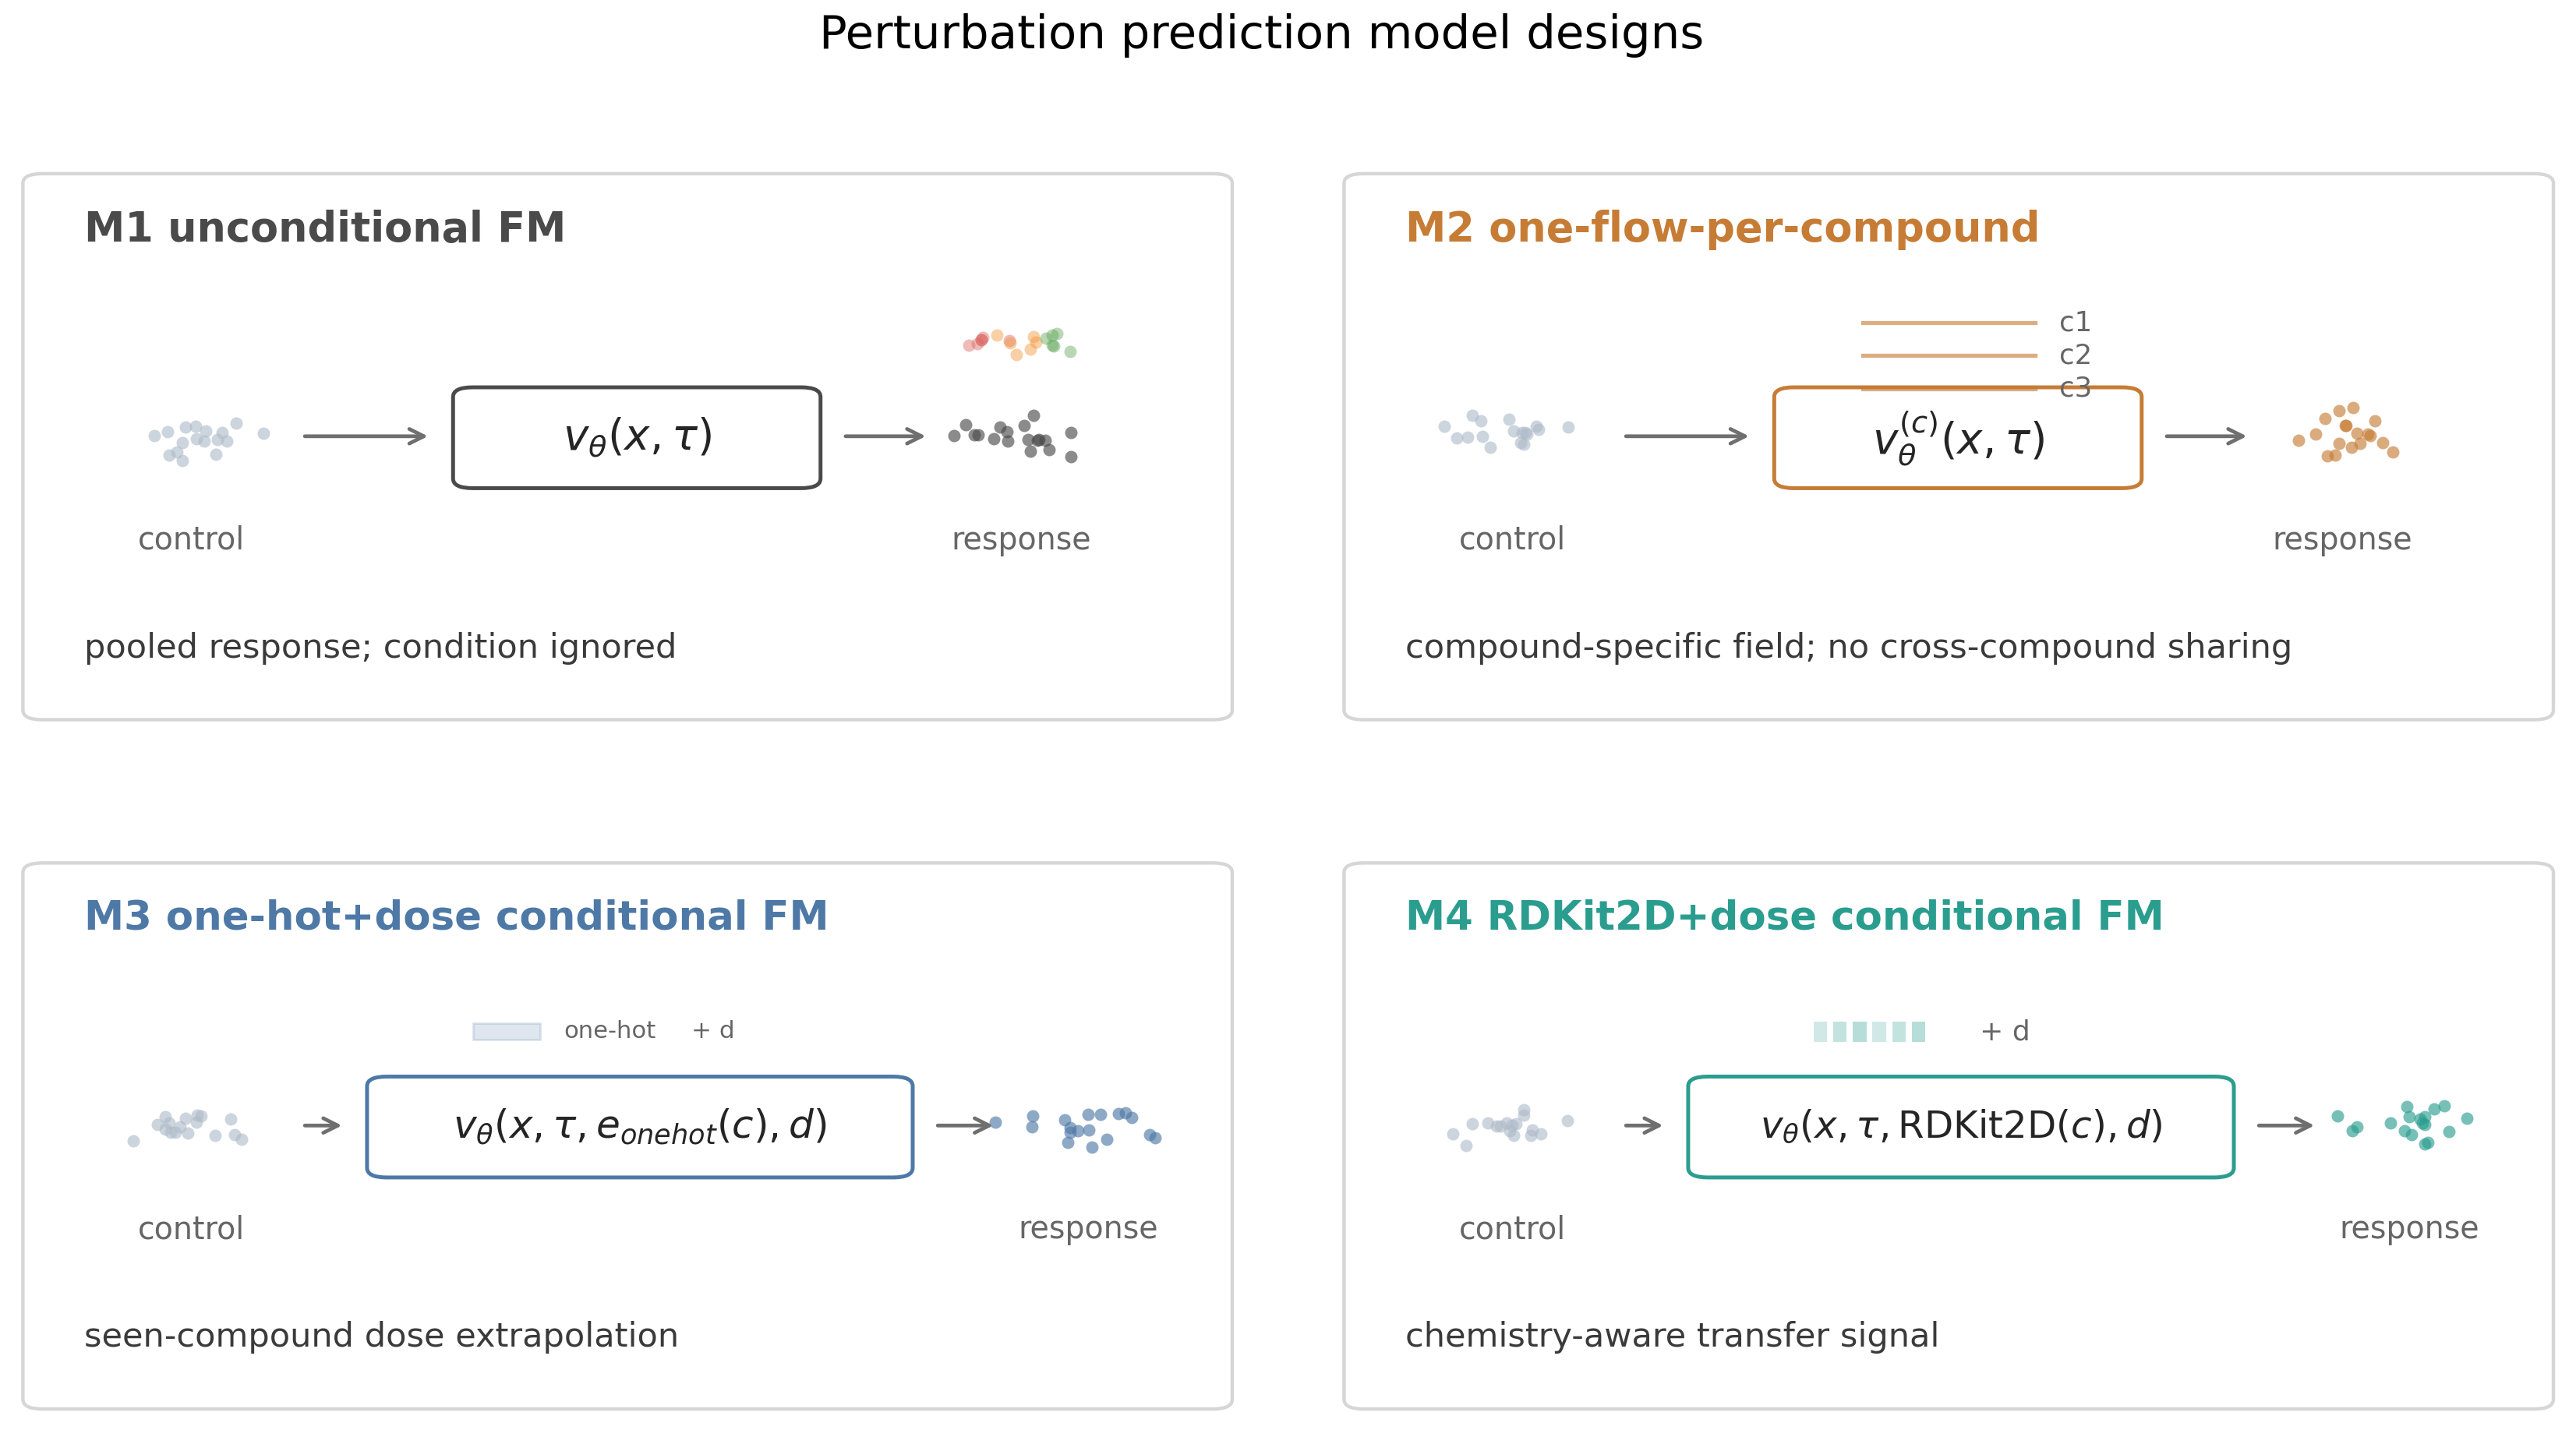

In [15]:
def draw_tiny_cloud(ax, center, color, seed_offset=0, n=18, sx=0.023, sy=0.018, alpha=0.62):
    local = np.random.default_rng(DEFAULT_SEED + seed_offset)
    pts = local.normal(size=(n, 2))
    pts[:, 0] = center[0] + pts[:, 0] * sx
    pts[:, 1] = center[1] + pts[:, 1] * sy
    ax.scatter(pts[:, 0], pts[:, 1], s=7.5, color=color, alpha=alpha, linewidths=0, clip_on=False)


def draw_velocity_box(ax, x, y, w, h, text, color, fontsize=8.8):
    patch = mpatches.FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.007,rounding_size=0.016",
        linewidth=0.85,
        edgecolor=color,
        facecolor="#FFFFFF",
    )
    ax.add_patch(patch)
    ax.text(x + w / 2, y + h / 2, text, ha="center", va="center", fontsize=fontsize, color="#252525")


def draw_method_tile(ax, method, formula, note, seed_offset):
    color = METHOD_COLORS[method]
    long_formula = method in {"M3_no_chemistry", "M4_chemistry_aware"}
    box_x = 0.295 if long_formula else 0.365
    box_w = 0.430 if long_formula else 0.285
    formula_size = 8.3 if method == "M4_chemistry_aware" else 8.6 if long_formula else 9.4
    response_x = 0.875 if long_formula else 0.82

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")
    tile = mpatches.FancyBboxPatch(
        (0.018, 0.035), 0.964, 0.895,
        boxstyle="round,pad=0.010,rounding_size=0.016",
        linewidth=0.75,
        edgecolor="#D6D6D6",
        facecolor="#FFFFFF",
    )
    ax.add_patch(tile)
    method_title_size = 8.8 if long_formula else 9.0
    ax.text(0.058, 0.880, METHOD_LABELS[method], ha="left", va="top", fontsize=method_title_size, weight="bold", color=color)

    draw_tiny_cloud(ax, (0.145, 0.50), "#AEBBC8", seed_offset=seed_offset, n=17)
    draw_velocity_box(ax, box_x, 0.420, box_w, 0.155, formula, color, fontsize=formula_size)
    draw_tiny_cloud(ax, (response_x, 0.50), color, seed_offset=seed_offset + 20, n=18, sx=0.026, sy=0.020, alpha=0.64)
    ax.annotate("", xy=(box_x - 0.020, 0.50), xytext=(0.230, 0.50), arrowprops={"arrowstyle": "->", "lw": 0.82, "color": "#6F6F6F"})
    ax.annotate("", xy=(response_x - 0.070, 0.50), xytext=(box_x + box_w + 0.020, 0.50), arrowprops={"arrowstyle": "->", "lw": 0.82, "color": "#6F6F6F"})
    ax.text(0.145, 0.325, "control", ha="center", va="center", fontsize=6.8, color="#666666")
    ax.text(response_x, 0.325, "response", ha="center", va="center", fontsize=6.8, color="#666666")

    if method == "M2_per_compound":
        for j, yy in enumerate([0.690, 0.635, 0.580]):
            ax.plot([0.43, 0.57], [yy, yy], color=color, lw=0.9, alpha=0.62)
            ax.text(0.590, yy, f"c{j + 1}", va="center", fontsize=6.1, color="#666666")
    elif method == "M3_no_chemistry":
        ax.add_patch(mpatches.Rectangle((0.374, 0.644), 0.055, 0.028, facecolor=color, alpha=0.18, edgecolor=color, linewidth=0.50))
        ax.text(0.448, 0.658, "one-hot", va="center", fontsize=5.25, color="#666666")
        ax.text(0.552, 0.658, "+ d", va="center", fontsize=5.35, color="#666666")
    elif method == "M4_chemistry_aware":
        for k in range(6):
            ax.add_patch(mpatches.Rectangle((0.390 + 0.016 * k, 0.640), 0.011, 0.034, facecolor=color, alpha=0.22 + 0.06 * (k % 3), edgecolor="none"))
        ax.text(0.525, 0.657, "+ d", va="center", fontsize=6.2, color="#666666")
    else:
        for j, resp_color in enumerate(["#D95F59", "#F28E2B", "#59A14F"]):
            draw_tiny_cloud(ax, (0.795 + 0.025 * j, 0.655), resp_color, seed_offset=seed_offset + 40 + j, n=6, sx=0.010, sy=0.009, alpha=0.42)

    ax.text(0.058, 0.145, note, ha="left", va="center", fontsize=7.4, color="#3A3A3A", wrap=True)


fig, axes = plt.subplots(2, 2, figsize=(8.2, 4.65))
fig.suptitle(FIGURE_TITLES["fig_5_2_model_designs"], fontsize=10.2, y=0.972)
method_tiles = [
    ("M1_unconditional", r"$v_\theta(x,\tau)$", "pooled response; condition ignored"),
    ("M2_per_compound", r"$v_\theta^{(c)}(x,\tau)$", "compound-specific field; no cross-compound sharing"),
    ("M3_no_chemistry", r"$v_\theta(x,\tau,e_{onehot}(c),d)$", "seen-compound dose extrapolation"),
    ("M4_chemistry_aware", r"$v_\theta(x,\tau,\mathrm{RDKit2D}(c),d)$", "chemistry-aware transfer signal"),
]
for i, (ax, (method, formula, note)) in enumerate(zip(axes.ravel(), method_tiles)):
    draw_method_tile(ax, method, formula, note, seed_offset=100 + i)
fig.subplots_adjust(left=0.035, right=0.985, bottom=0.045, top=0.890, wspace=0.075, hspace=0.155)
figure_paths["fig_5_2_model_designs"] = save_figure_pair(fig, "fig_5_2_model_designs", tight=False)
display_saved_figure(figure_paths["fig_5_2_model_designs"])


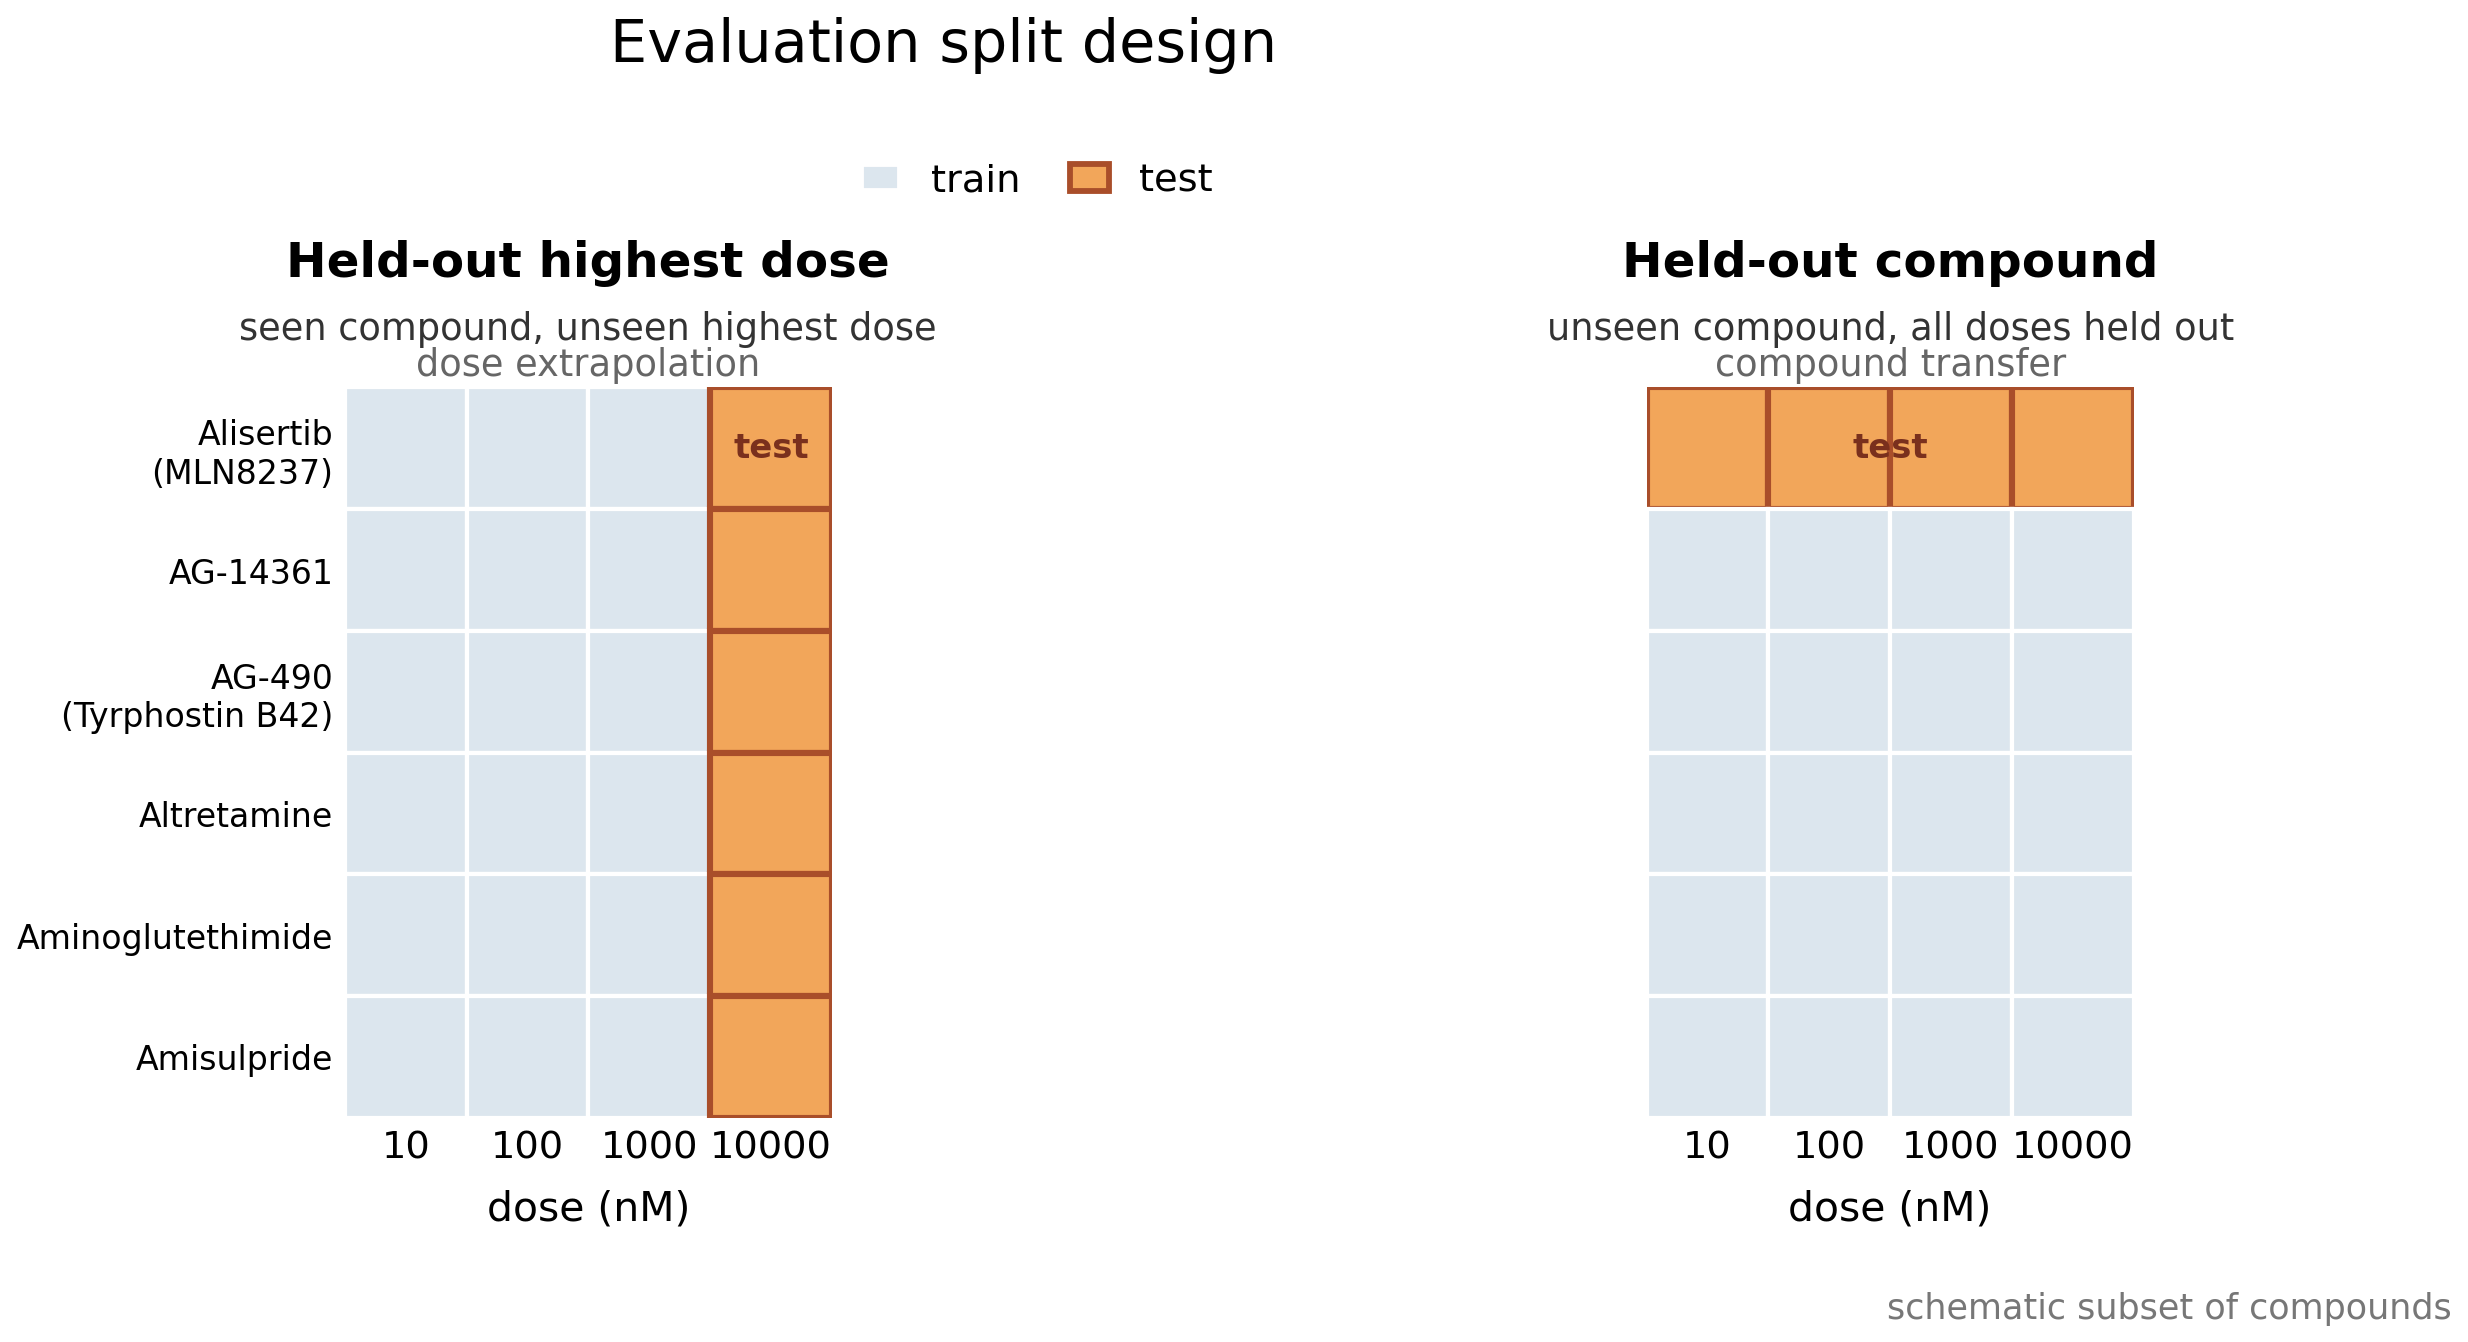

In [16]:
compounds_all = sorted(metadata.loc[~metadata["is_vehicle"], "compound"].astype(str).unique().tolist())
doses_for_grid = [10.0, 100.0, 1000.0, 10000.0]
priority_compounds = ["Alisertib (MLN8237)", "BMS-754807", "Crizotinib", "Dacinostat", "Givinostat", "Quisinostat"]
compounds_for_grid = [compound for compound in priority_compounds if compound in compounds_all]
for compound in compounds_all:
    if len(compounds_for_grid) >= 6:
        break
    if compound not in compounds_for_grid:
        compounds_for_grid.append(compound)


def split_status_matrix(split_meta):
    status = pd.DataFrame("missing", index=compounds_for_grid, columns=doses_for_grid)
    treated = split_meta.loc[~split_meta["is_vehicle"].astype(bool)].copy()
    for compound in compounds_for_grid:
        for dose in doses_for_grid:
            group = treated.loc[treated["compound"].astype(str).eq(compound) & np.isclose(treated["dose"].astype(float), dose)]
            if group.empty:
                continue
            if group["split"].eq("test").any():
                status.loc[compound, dose] = "test"
            elif group["split"].eq("train").any():
                status.loc[compound, dose] = "train"
    return status


def draw_split_grid(ax, status, title, boundary_label, claim_label):
    n_rows, n_cols = status.shape
    colors = {"train": "#DCE6EE", "test": "#F2A65A", "missing": "#F6F6F6"}
    test_cells = []
    for r, compound in enumerate(status.index):
        y = n_rows - 1 - r
        for c, dose in enumerate(status.columns):
            value = status.loc[compound, dose]
            edge = "#A94E2A" if value == "test" else "#FFFFFF"
            lw = 1.05 if value == "test" else 0.72
            ax.add_patch(mpatches.Rectangle((c, y), 1, 1, facecolor=colors[value], edgecolor=edge, linewidth=lw))
            if value == "test":
                test_cells.append((c, y))
    if test_cells:
        coords = np.asarray(test_cells, dtype=float)
        cols = np.unique(coords[:, 0])
        rows = np.unique(coords[:, 1])
        if len(cols) == 1:
            label_x = float(cols[0] + 0.5)
            label_y = float(rows.max() + 0.5)
        elif len(rows) == 1:
            label_x = float(coords[:, 0].mean() + 0.5)
            label_y = float(rows[0] + 0.5)
        else:
            label_x = float(coords[:, 0].mean() + 0.5)
            label_y = float(coords[:, 1].mean() + 0.5)
        ax.text(label_x, label_y, "test", ha="center", va="center", fontsize=5.8, color="#7A301D", weight="bold")
    ax.set_xlim(0, n_cols)
    ax.set_ylim(0, n_rows)
    ax.set_aspect("equal")
    ax.set_xticks(np.arange(n_cols) + 0.5)
    ax.set_xticklabels([f"{dose:g}" for dose in status.columns], fontsize=6.6)
    ax.set_yticks(np.arange(n_rows) + 0.5)
    ax.set_yticklabels([short_compound_label(c, width=18) for c in reversed(status.index)], fontsize=5.7)
    ax.tick_params(length=0, pad=2)
    ax.set_xlabel("dose (nM)", fontsize=7.0, labelpad=4)
    ax.set_title(title, fontsize=8.3, pad=19, weight="bold")
    ax.text(0.5, 1.055, boundary_label, transform=ax.transAxes, ha="center", va="bottom", fontsize=6.3, color="#333333")
    ax.text(0.5, 1.005, claim_label, transform=ax.transAxes, ha="center", va="bottom", fontsize=6.3, color="#666666")
    for spine in ax.spines.values():
        spine.set_visible(False)


fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.25), sharey=True)
draw_split_grid(
    axes[0],
    split_status_matrix(split_b),
    "Held-out highest dose",
    "seen compound, unseen highest dose",
    "dose extrapolation",
)
draw_split_grid(
    axes[1],
    split_status_matrix(split_c),
    "Held-out compound",
    "unseen compound, all doses held out",
    "compound transfer",
)
handles = [
    mpatches.Patch(facecolor="#DCE6EE", edgecolor="#FFFFFF", label="train"),
    mpatches.Patch(facecolor="#F2A65A", edgecolor="#A94E2A", label="test"),
]
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.53, 0.895), ncol=2, frameon=False, handlelength=1.0, columnspacing=1.3, fontsize=6.6)
fig.text(0.985, 0.018, "schematic subset of compounds", ha="right", va="bottom", fontsize=6.0, color="#777777")
fig.suptitle(FIGURE_TITLES["fig_5_2_evaluation_splits"], fontsize=10.1, y=0.977)
fig.subplots_adjust(left=0.205, right=0.985, bottom=0.17, top=0.705, wspace=0.16)
figure_paths["fig_5_2_evaluation_splits"] = save_figure_pair(fig, "fig_5_2_evaluation_splits", tight=False)
display_saved_figure(figure_paths["fig_5_2_evaluation_splits"])


In [17]:
def plot_metric_panel(frame, title, stem, note=None):
    metrics = [("MMD", "MMD", "{:.4f}"), ("Sliced W2", "Sliced W2", "{:.3f}")]
    n = len(frame)
    y = np.arange(n - 1, -1, -1)
    labels = [METHOD_LABELS[method] for method in frame["method"]]
    fig, axes = plt.subplots(1, 2, figsize=(8.0, 3.25), sharey=True)
    baseline_methods = {"vehicle_as_prediction", "mean_shift", "nearest_chemistry"}
    model_count = sum(method not in baseline_methods for method in frame["method"])
    separator_y = n - model_count - 0.5

    for ax, (col, metric_title, fmt) in zip(axes, metrics):
        values = frame[col].to_numpy(dtype=float)
        colors = [METHOD_COLORS[method] for method in frame["method"]]
        edge_colors = ["#8A8A8A" if method in baseline_methods else "#333333" for method in frame["method"]]
        ax.barh(y, values, height=0.58, color=colors, edgecolor=edge_colors, linewidth=0.45)
        ax.axhline(separator_y, color="#BDBDBD", linewidth=0.6, linestyle=(0, (2.2, 2.2)), zorder=0)
        ax.set_yticks(y)
        ax.set_yticklabels(labels, fontsize=6.9)
        ax.set_ylim(-0.60, n - 0.30)
        ax.set_xlabel("metric value", fontsize=7.0)
        ax.set_title(metric_title, fontsize=8.3, pad=5)
        ax.text(0.99, 1.025, "lower is better", transform=ax.transAxes, ha="right", va="bottom", fontsize=6.0, color="#8A8A8A")
        ax.grid(axis="x", color="#E8E8E8", linewidth=0.42)
        ax.set_axisbelow(True)
        xmax = max(float(np.nanmax(values)) * 1.25, 1e-6)
        ax.set_xlim(0, xmax)
        for yi, value in zip(y, values):
            ax.text(value + xmax * 0.018, yi, fmt.format(value), ha="left", va="center", fontsize=6.6, color="#333333")
        ax.tick_params(axis="x", labelsize=6.7, length=2, width=0.55)
        ax.tick_params(axis="y", length=0, pad=3)
        for spine in ["left", "bottom"]:
            ax.spines[spine].set_linewidth(0.6)
            ax.spines[spine].set_color("#777777")
    axes[1].tick_params(axis="y", labelleft=False)
    if note:
        fig.text(0.055, 0.030, note, ha="left", va="bottom", fontsize=6.2, color="#666666")
    fig.suptitle(title, fontsize=10.3, y=0.978)
    fig.subplots_adjust(left=0.315, right=0.985, bottom=0.175, top=0.805, wspace=0.10)
    return save_figure_pair(fig, stem, tight=False)


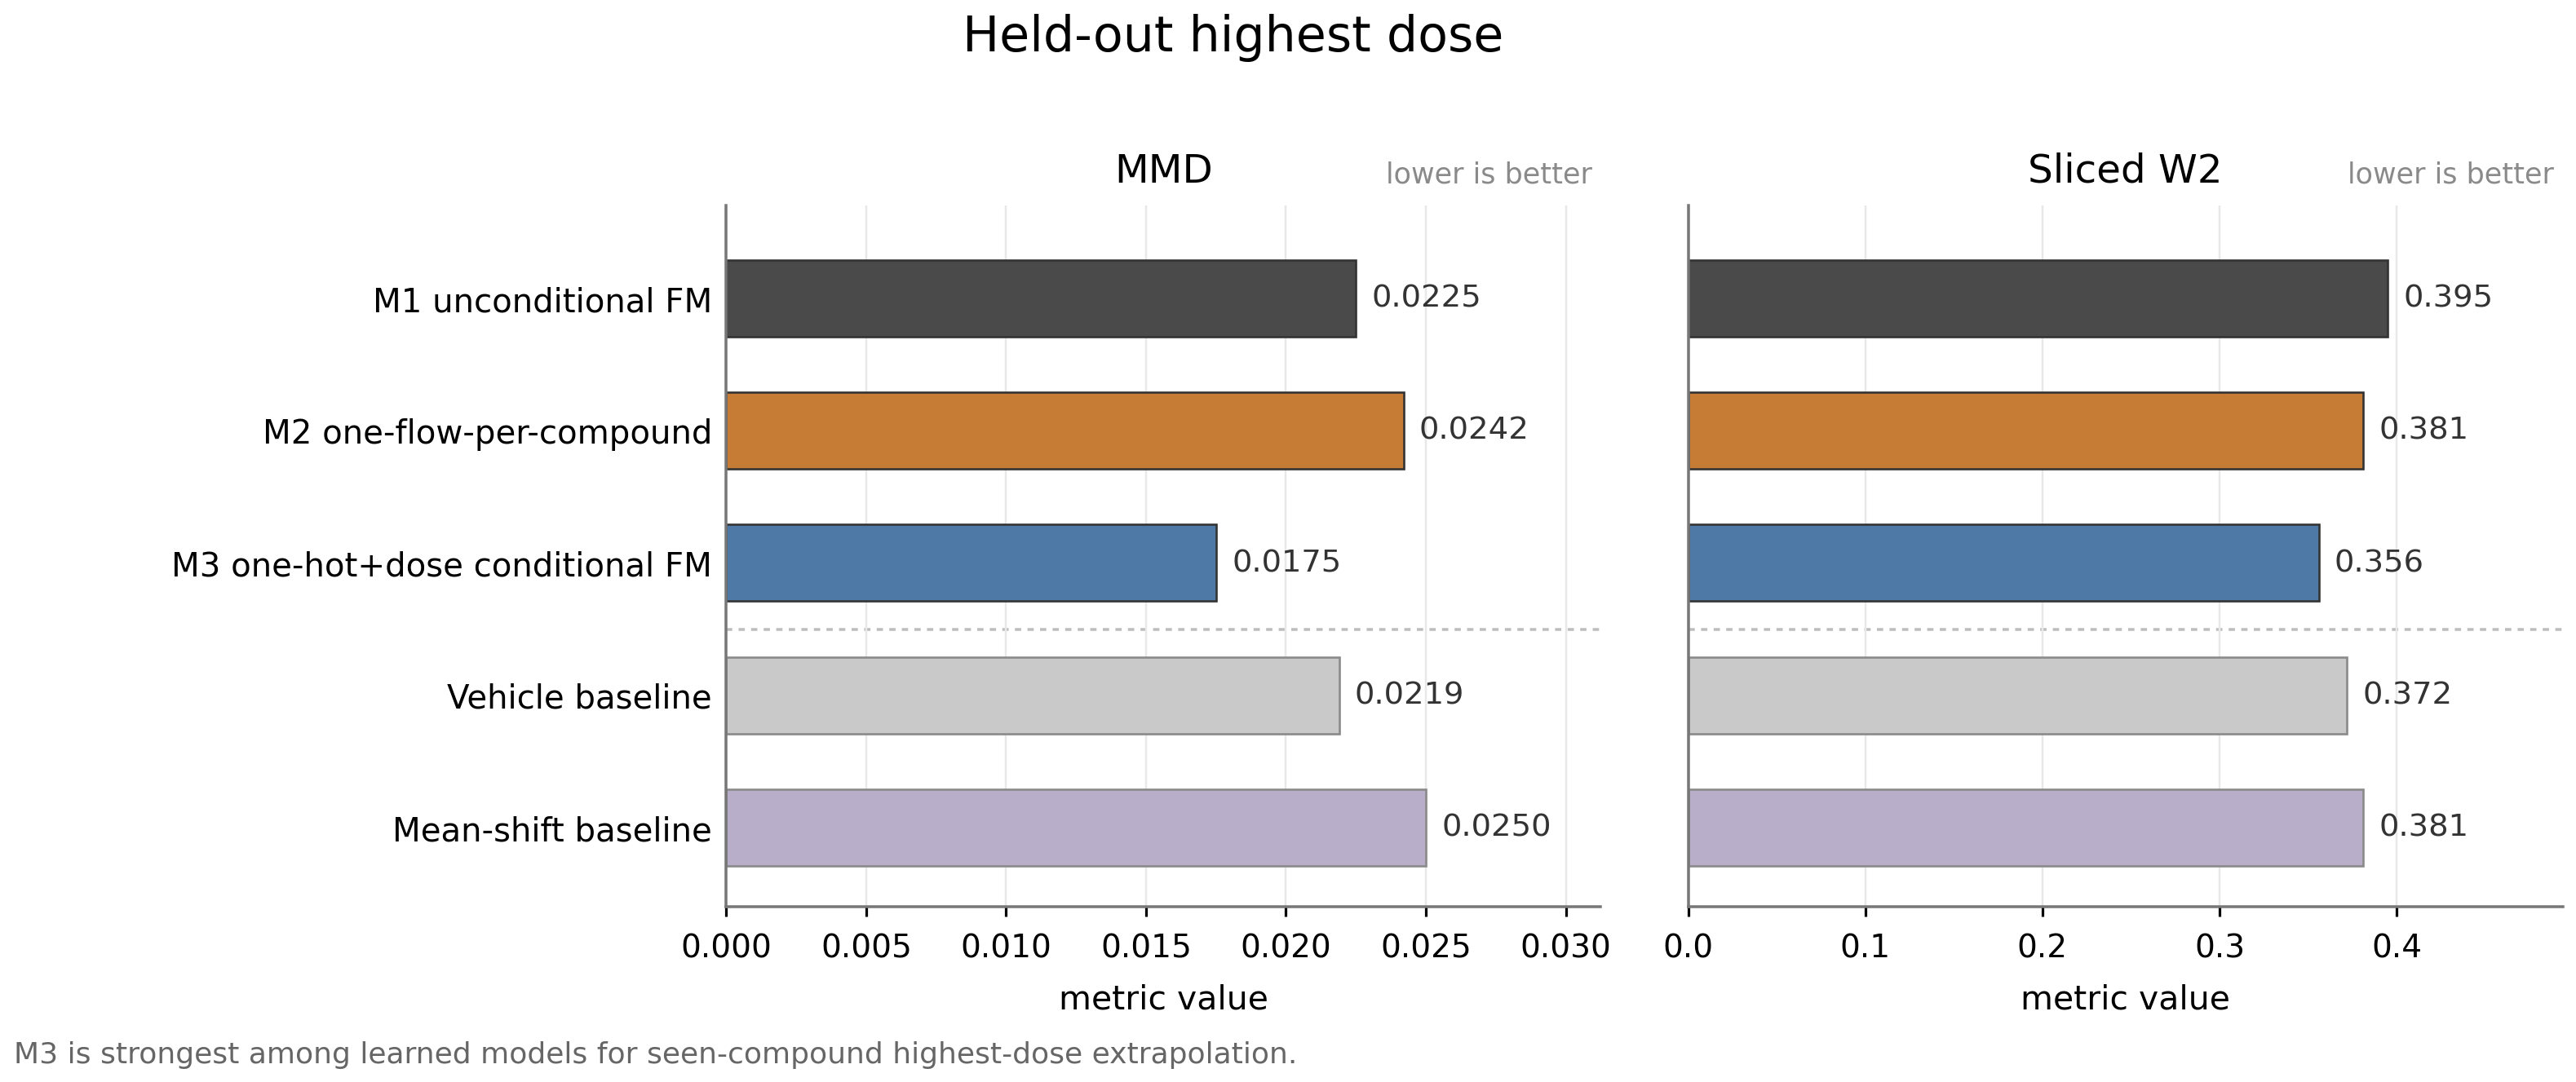

In [18]:
figure_paths["fig_5_2_heldout_highest_dose_metrics"] = plot_metric_panel(
    split_b_metric_display,
    FIGURE_TITLES["fig_5_2_heldout_highest_dose_metrics"],
    "fig_5_2_heldout_highest_dose_metrics",
    note="M3 is strongest among learned models for seen-compound highest-dose extrapolation.",
)
display_saved_figure(figure_paths["fig_5_2_heldout_highest_dose_metrics"])


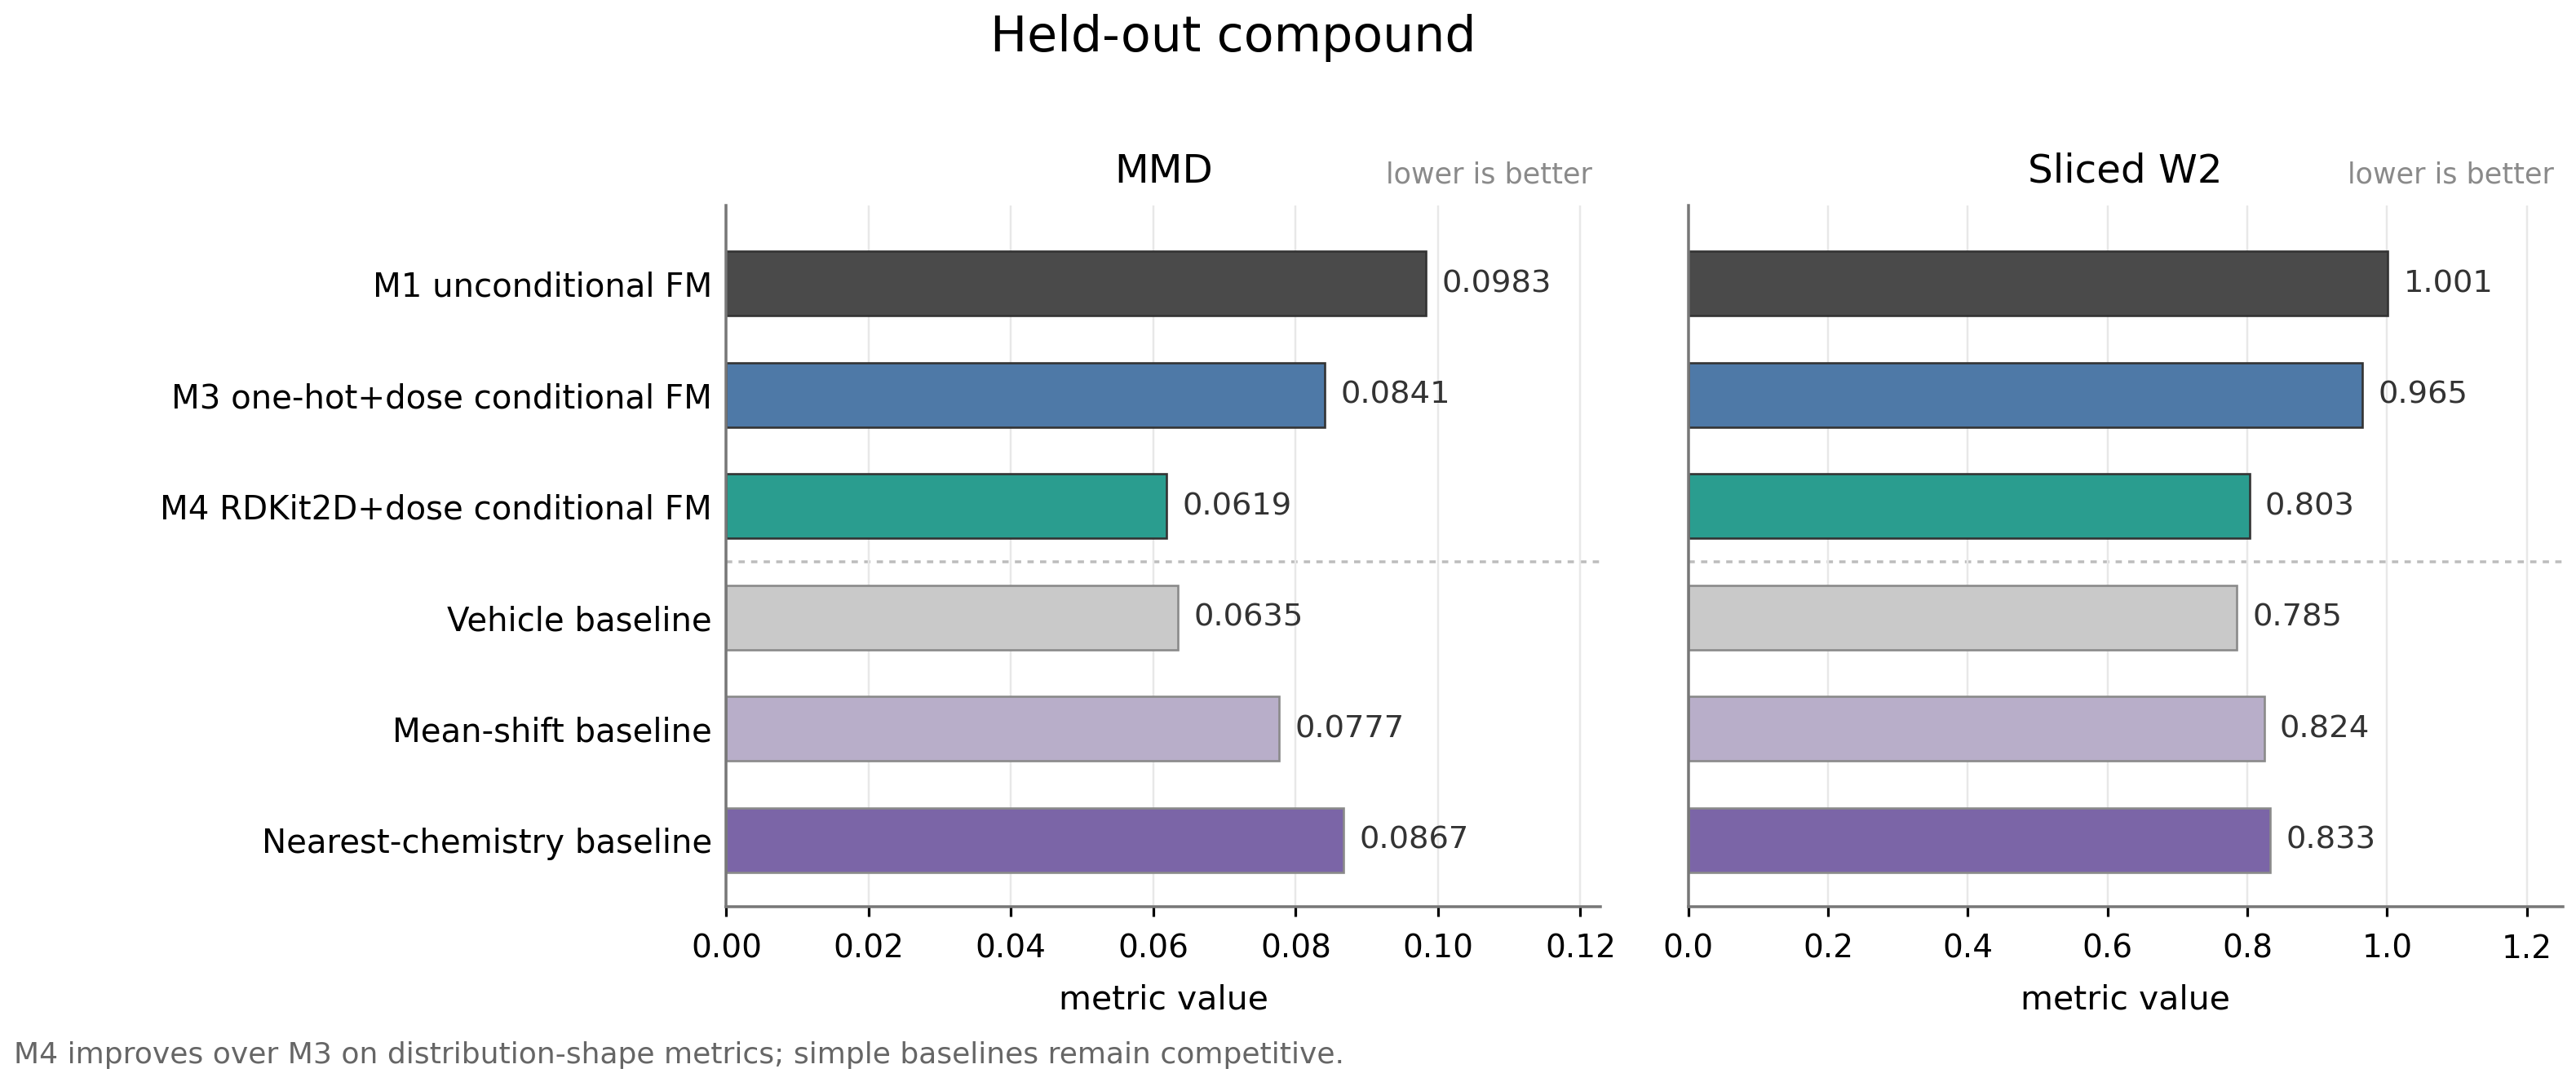

In [19]:
figure_paths["fig_5_2_heldout_compound_metrics"] = plot_metric_panel(
    split_c_metric_display,
    FIGURE_TITLES["fig_5_2_heldout_compound_metrics"],
    "fig_5_2_heldout_compound_metrics",
    note="M4 improves over M3 on distribution-shape metrics; simple baselines remain competitive.",
)
display_saved_figure(figure_paths["fig_5_2_heldout_compound_metrics"])


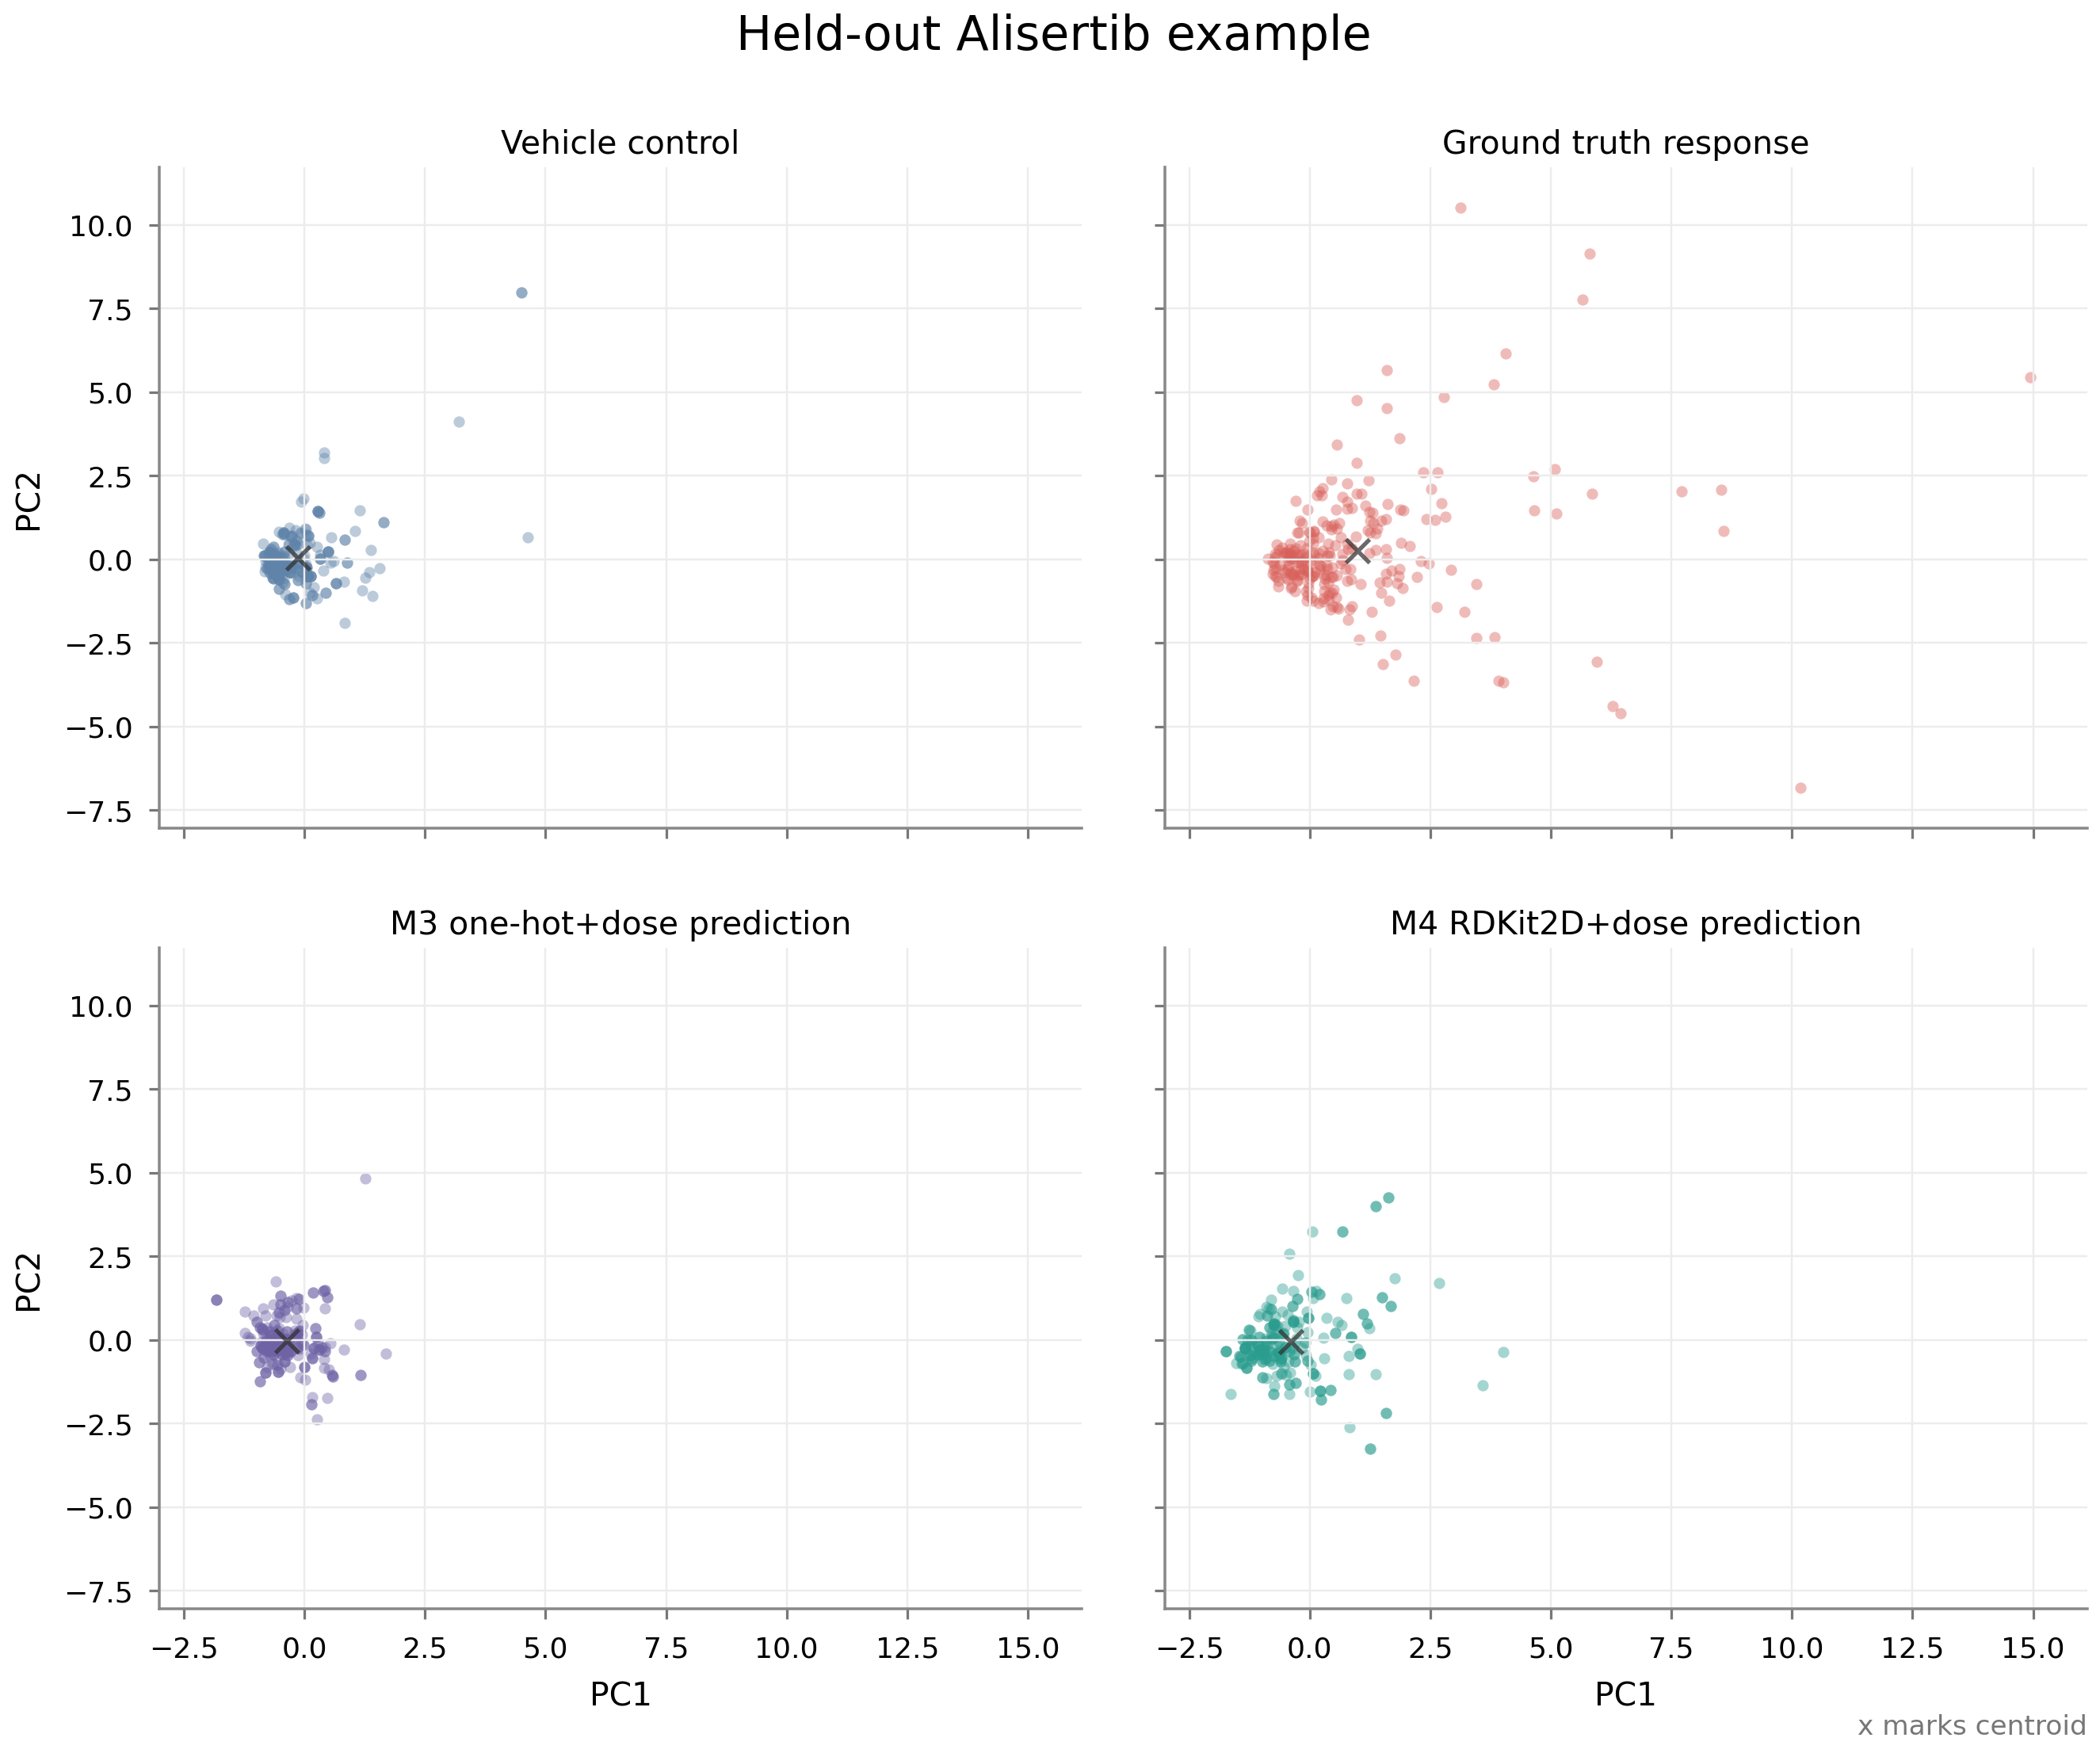

In [20]:
alisertib_keys = [key for key in split_c_cache["predictions"] if "Alisertib" in str(key[0])]
if alisertib_keys:
    representative_key = sorted(alisertib_keys, key=lambda x: x[1])[-1]
else:
    heldout_keys = [key for key in split_c_cache["predictions"] if key[0] == heldout_compound]
    if not heldout_keys:
        heldout_keys = list(split_c_cache["predictions"].keys())
    representative_key = sorted(heldout_keys, key=lambda x: x[1])[-1]
panel = split_c_cache["predictions"][representative_key]

scatter_panels = [
    ("Vehicle control", panel["vehicle_as_prediction"], SCATTER_COLORS["vehicle"]),
    ("Ground truth response", panel["target"], SCATTER_COLORS["truth"]),
    ("M3 one-hot+dose prediction", panel["M3_no_chemistry"], SCATTER_COLORS["m3"]),
    ("M4 RDKit2D+dose prediction", panel["M4_chemistry_aware"], SCATTER_COLORS["m4"]),
]
all_points = np.vstack([np.asarray(points)[:, :2] for _, points, _ in scatter_panels])
x_pad = 0.07 * max(float(all_points[:, 0].max() - all_points[:, 0].min()), 1e-6)
y_pad = 0.07 * max(float(all_points[:, 1].max() - all_points[:, 1].min()), 1e-6)
xlim = (float(all_points[:, 0].min() - x_pad), float(all_points[:, 0].max() + x_pad))
ylim = (float(all_points[:, 1].min() - y_pad), float(all_points[:, 1].max() + y_pad))

fig, axes = plt.subplots(2, 2, figsize=(6.4, 5.45), sharex=True, sharey=True)
for ax, (title, points, color) in zip(axes.ravel(), scatter_panels):
    points = np.asarray(points)
    ax.scatter(points[:, 0], points[:, 1], s=6, alpha=0.42, linewidths=0, color=color, rasterized=True)
    center = points[:, :2].mean(axis=0)
    ax.scatter(center[0], center[1], s=26, marker="x", color="#2F2F2F", linewidths=0.9, alpha=0.72, zorder=3)
    ax.set_title(title, fontsize=7.0, pad=3)
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.grid(color="#ECECEC", linewidth=0.42)
    ax.tick_params(labelsize=6.2, length=2.2, width=0.55, color="#777777")
    ax.spines["left"].set_color("#888888")
    ax.spines["bottom"].set_color("#888888")
    ax.spines["left"].set_linewidth(0.6)
    ax.spines["bottom"].set_linewidth(0.6)
for ax in axes[:, 0]:
    ax.set_ylabel("PC2", fontsize=7.0)
for ax in axes[-1, :]:
    ax.set_xlabel("PC1", fontsize=7.0)
fig.text(0.985, 0.028, "x marks centroid", ha="right", va="bottom", fontsize=5.9, color="#777777")
fig.suptitle(FIGURE_TITLES["fig_5_2_alisertib_example"], fontsize=10.3, y=0.980)
fig.subplots_adjust(left=0.08, right=0.985, bottom=0.10, top=0.895, wspace=0.09, hspace=0.18)
figure_paths["fig_5_2_alisertib_example"] = save_figure_pair(fig, "fig_5_2_alisertib_example", tight=False)

RUN_SUMMARY["sciplex_representative_heldout"] = {
    "compound": representative_key[0],
    "dose": representative_key[1],
    "split_name": "Split C held-out compound",
}
display_saved_figure(figure_paths["fig_5_2_alisertib_example"])


## 6. Artifact manifest, run summary, and final checks

The final cells define the required independent figure artifacts, record data-source provenance for each figure, write the run summary, verify finite numeric metrics, and fail loudly if any expected path is missing or empty.

In [21]:
required_figure_stems = [
    "fig_5_2_model_designs",
    "fig_5_2_evaluation_splits",
    "fig_5_2_heldout_highest_dose_metrics",
    "fig_5_2_heldout_compound_metrics",
    "fig_5_2_alisertib_example",
]
required_figure_paths = []
for stem in required_figure_stems:
    required_figure_paths.extend([figure_paths[stem]["png"], figure_paths[stem]["pdf"]])
required_paths = [
    *required_figure_paths,
    TABLE_DIR / "tab_5_2_sciplex_splits.csv",
    OUT_DIR / "rdkit2d_compound_features.npz",
    OUT_DIR / "rdkit2d_diagnostics.json",
    OUT_DIR / "rdkit2d_audit.csv",
    OUT_DIR / "sciplex_metrics_by_group.csv",
    OUT_DIR / "sciplex_metrics_summary.csv",
    OUT_DIR / "real_data_audit.json",
    OUT_DIR / "run_summary_perturbation_sciplex.json",
]

metric_frames = {
    "split_b_metrics": split_b_metrics,
    "split_c_metrics": split_c_metrics,
    "sciplex_metrics": sciplex_metrics,
    "sciplex_summary": sciplex_summary,
    "split_b_metric_display": split_b_metric_display,
    "split_c_metric_display": split_c_metric_display,
}
finite_checks = {}
for name, frame in metric_frames.items():
    numeric = frame.select_dtypes(include=[np.number])
    finite_checks[name] = bool(np.isfinite(numeric.to_numpy()).all()) if numeric.size else True

figure_data_sources = {
    "fig_5_2_model_designs": "deterministic schematic from Section 5.2 model definitions; no experimental metrics",
    "fig_5_2_evaluation_splits": "split_b, split_c, metadata, and tables/ch05/tab_5_2_sciplex_splits.csv",
    "fig_5_2_heldout_highest_dose_metrics": "split_b_metric_display synchronized to manuscript main-text table; raw cached metrics remain in outputs/ch05/sciplex_metrics_summary.csv",
    "fig_5_2_heldout_compound_metrics": "split_c_metric_display synchronized to manuscript main-text table; raw cached metrics remain in outputs/ch05/sciplex_metrics_summary.csv",
    "fig_5_2_alisertib_example": "split_c_cache['predictions'][representative_key] and split-aware PCA state states['Split C held-out compound']",
}
figure_title_audit = pd.DataFrame([
    {"figure": stem, "title": FIGURE_TITLES[stem], "has_panel_letter_prefix": False}
    for stem in required_figure_stems
])
forbidden_title_tokens = ("A.", "B.", "C.", "D.", "Panel A", "Panel B", "Panel C", "Panel D")
if any(str(title).startswith(forbidden_title_tokens) or "Panel " in str(title) for title in FIGURE_TITLES.values()):
    raise ValueError("A figure title contains an A/B/C/D panel-style prefix.")

formula_strings = [
    r"$v_\theta(x,\tau)$",
    r"$v_\theta^{(c)}(x,\tau)$",
    r"$v_\theta(x,\tau,e_{onehot}(c),d)$",
    r"$v_\theta(x,\tau,\mathrm{RDKit2D}(c),d)$",
]
code_style_formula_tokens = ["v" + "_theta", "RDKit2D" + "(c), " + "dose", "e" + "(c)"]
source_for_formula_check = "\n".join(formula_strings)
if any(token in source_for_formula_check for token in code_style_formula_tokens):
    raise ValueError("Code-style formula text reached formula labels.")

if not missing_result_notes:
    missing_result_notes.append("No requested plotted model, baseline, or metric is missing.")

section52_summary = {
    "generated_files": [str(path.relative_to(PROJECT_ROOT)) for path in required_figure_paths],
    "figure_data_sources": figure_data_sources,
    "metric_display_source": manuscript_metric_source,
    "raw_metric_source": "sciplex_summary from outputs/ch05/sciplex_metrics_summary.csv",
    "heldout_highest_dose_metrics": metric_value_table(split_b_metric_display),
    "heldout_compound_metrics": metric_value_table(split_c_metric_display),
    "alisertib_scatter": {
        "compound": representative_key[0],
        "dose": float(representative_key[1]),
        "split_name": "Split C held-out compound",
        "source_variable": "split_c_cache['predictions'][representative_key]",
    },
    "missing_or_not_applicable": missing_result_notes,
    "no_panel_letter_titles": True,
    "no_code_style_formula_text": True,
    "combined_figure_generated": False,
    "interpretation_note": (
        "M4 improves over M3 on held-out-compound distribution-shape metrics; "
        "vehicle and mean-shift baselines remain competitive and are visually separated as baselines."
    ),
}

RUN_SUMMARY["splits_evaluated"] = [
    "Split B held-out highest dose",
    "Split C held-out compound",
]
RUN_SUMMARY["key_metrics"] = {
    "heldout_highest_dose": metric_value_table(split_b_metric_display),
    "heldout_compound": metric_value_table(split_c_metric_display),
    "representative_heldout": RUN_SUMMARY.get("sciplex_representative_heldout", {}),
}
RUN_SUMMARY["section52_independent_figures"] = {
    stem: {fmt: str(path.relative_to(PROJECT_ROOT)) for fmt, path in paths.items()}
    for stem, paths in figure_paths.items()
}
RUN_SUMMARY["section52_figure_summary"] = section52_summary
RUN_SUMMARY["finite_metric_checks"] = finite_checks
RUN_SUMMARY["expected_artifacts"] = [str(path.relative_to(PROJECT_ROOT)) for path in required_paths]
if bool(RUN_SUMMARY["sciplex_data"]["summary"].get("is_synthetic", False)):
    raise ValueError("Synthetic sci-Plex data reached final summary; refusing to write perturbation run summary.")
if "synthetic" in str(RUN_SUMMARY["sciplex_data"]["summary"].get("source", "")).lower():
    raise ValueError("Synthetic-labeled sci-Plex source reached final summary; refusing to write perturbation run summary.")
save_json(OUT_DIR / "run_summary_perturbation_sciplex.json", RUN_SUMMARY)


PosixPath('/home/xmabs/flow_matching_for_dynamic_biology/flow_matching_for_dynamic_biology/outputs/ch05/run_summary_perturbation_sciplex.json')

In [22]:
missing_paths = []
for path in required_paths:
    if not path.exists() or path.stat().st_size <= 0:
        missing_paths.append(str(path))
if missing_paths:
    raise FileNotFoundError(f"Missing or empty required artifacts: {missing_paths}")
if not all(finite_checks.values()):
    raise ValueError(f"Non-finite numeric metrics detected: {finite_checks}")

artifact_table = pd.DataFrame({
    "path": [str(path.relative_to(PROJECT_ROOT)) for path in required_paths],
    "bytes": [path.stat().st_size for path in required_paths],
})
print("Generated independent Section 5.2 figure files:")
for path in required_figure_paths:
    print(path.relative_to(PROJECT_ROOT), path.stat().st_size)

print("\nFigure data sources:")
for figure, source in figure_data_sources.items():
    print(f"{figure}: {source}")

print("\nHeld-out highest dose metrics used for the figure (lower is better):")
display(metric_value_table(split_b_metric_display))
print("Held-out compound metrics used for the figure (lower is better):")
display(metric_value_table(split_c_metric_display))
print("Alisertib scatter selection:", section52_summary["alisertib_scatter"])
print("Missing or not applicable models/baselines/metrics:")
for note in missing_result_notes:
    print("-", note)
print("No A/B/C/D or Panel A style prefixes in small-figure titles:", section52_summary["no_panel_letter_titles"])
print("No code-style formula labels in model schematic:", section52_summary["no_code_style_formula_text"])
print("Combined figure generated:", section52_summary["combined_figure_generated"])

display(artifact_table)
display(figure_title_audit)
display(pd.DataFrame({"metric_frame": list(finite_checks), "all_finite": list(finite_checks.values())}))


Generated independent Section 5.2 figure files:
figures/ch05/new2/fig_5_2_model_designs.png 271021
figures/ch05/new2/fig_5_2_model_designs.pdf 36223
figures/ch05/new2/fig_5_2_evaluation_splits.png 144850
figures/ch05/new2/fig_5_2_evaluation_splits.pdf 20524
figures/ch05/new2/fig_5_2_heldout_highest_dose_metrics.png 168613
figures/ch05/new2/fig_5_2_heldout_highest_dose_metrics.pdf 14184
figures/ch05/new2/fig_5_2_heldout_compound_metrics.png 187167
figures/ch05/new2/fig_5_2_heldout_compound_metrics.pdf 15051
figures/ch05/new2/fig_5_2_alisertib_example.png 234103
figures/ch05/new2/fig_5_2_alisertib_example.pdf 48108

Figure data sources:
fig_5_2_model_designs: deterministic schematic from Section 5.2 model definitions; no experimental metrics
fig_5_2_evaluation_splits: split_b, split_c, metadata, and tables/ch05/tab_5_2_sciplex_splits.csv
fig_5_2_heldout_highest_dose_metrics: split_b_metric_display synchronized to manuscript main-text table; raw cached metrics remain in outputs/ch05/scipl

,method,MMD,Sliced W2
6,M1 unconditional FM,0.0225,0.395
7,M2 one-flow-per-compound,0.0242,0.381
8,M3 one-hot+dose conditional FM,0.0175,0.356
11,Vehicle baseline,0.0219,0.372
10,Mean-shift baseline,0.0250,0.381


Held-out compound metrics used for the figure (lower is better):


,method,MMD,Sliced W2
12,M1 unconditional FM,0.0983,1.001
13,M3 one-hot+dose conditional FM,0.0841,0.965
14,M4 RDKit2D+dose conditional FM,0.0619,0.803
17,Vehicle baseline,0.0635,0.785
15,Mean-shift baseline,0.0777,0.824
16,Nearest-chemistry baseline,0.0867,0.833


Alisertib scatter selection: {'compound': 'Alisertib (MLN8237)', 'dose': 10000.0, 'split_name': 'Split C held-out compound', 'source_variable': "split_c_cache['predictions'][representative_key]"}
Missing or not applicable models/baselines/metrics:
- M2 one-flow-per-compound is not plotted for held-out compound because an unseen compound has no trained per-compound flow.
No A/B/C/D or Panel A style prefixes in small-figure titles: True
No code-style formula labels in model schematic: True
Combined figure generated: False


,path,bytes
0,figures/ch05/new2/fig_5_2_model_designs.png,271021
1,figures/ch05/new2/fig_5_2_model_designs.pdf,36223
2,figures/ch05/new2/fig_5_2_evaluation_splits.png,144850
3,figures/ch05/new2/fig_5_2_evaluation_splits.pdf,20524
4,figures/ch05/new2/fig_5_2_heldout_highest_dose...,168613
5,figures/ch05/new2/fig_5_2_heldout_highest_dose...,14184
6,figures/ch05/new2/fig_5_2_heldout_compound_met...,187167
7,figures/ch05/new2/fig_5_2_heldout_compound_met...,15051
8,figures/ch05/new2/fig_5_2_alisertib_example.png,234103
9,figures/ch05/new2/fig_5_2_alisertib_example.pdf,48108


,figure,title,has_panel_letter_prefix
0,fig_5_2_model_designs,Perturbation prediction model designs,False
1,fig_5_2_evaluation_splits,Evaluation split design,False
2,fig_5_2_heldout_highest_dose_metrics,Held-out highest dose,False
3,fig_5_2_heldout_compound_metrics,Held-out compound,False
4,fig_5_2_alisertib_example,Held-out Alisertib example,False


,metric_frame,all_finite
0,split_b_metrics,True
1,split_c_metrics,True
2,sciplex_metrics,True
3,sciplex_summary,True
4,split_b_metric_display,True
5,split_c_metric_display,True
